# Índice
---

- A. Introducción
- B. Información previa a tener en cuenta
- C. Modelo propuesto
  - Origen de los datos
- D. Implementación del modelo
    - 1. Dataset y definición de los objetivos de entrenamiento
      - 1.1. Dataset
      - 1.2. División del dataset en conjuntos de entrenamiento, validación y pruebas
    - 2. Entrenamiento de algunos modelos de predicción
      - 2.1. Entrenamiento para regresión multisalida
        - Regresión Linear
        - Árboles de decisión
        - KNN
        - SVR
        - Red neuronal MLP
      - 2.2. Entrenamiento para clasificación
        - 2.2.1. Clasificación por tipo de localización
          - SVM
          - MLP
          - Random Forest
          - (CatBoost)
        - 2.2.2. Clasificación por escenario posible
          - SVM: no es posible debido a DF.
        - 2.2.3. Clasificación por estado del sujeto
          - SVM
          - MLP
          - Random Forest
    - 3. Comparación de resultados de los modelos de predicción
      - 3.1. Comparación de resultados de los modelos de regresión
      - 3.2. Comparación de resultados de los modelos de clasificación
        - Tipo de localización
        - Estado del sujeto
    - 4. Definición de un mapa de una zona
    - 5. Ejecución del modelo Monte Carlo
      - 5.1. Definición del modelo
      - 5.2. Generación de agentes
      - 5.3. Visualización sobre el mapa
    - 6. Obtención del mapa de calor de POA
    - 7. Cálculo POD
    - 8. Cálculo POS
    - 9. Asignación de recursos personales para cada área
- E. Conclusiones




# A. Introducción
---

Este documento corresponde al apartado de experimentación del modelo predictivo del Trabajo de Fin de Máster 'AlertRes, diseño de una aplicación de búsqueda y rescate de personas desaparecidas' del máster en Ingeniería Biomédica y Salud Digital de la Universidad de Sevilla. El objetivo final del trabajo es crear una aplicación de apoyo a la búsqueda y rescate de personas desaparecidas. Por ello se recomienda la lectura del trabajo para complementar la información.




# B. Información previa a tener en cuenta
---

Para este trabajo se usarán distintas librerías de python que se tendrán que tener instaladas para la correcta ejecución del trabajo.
En concreto son necesarios los paquetes:
- numpy
- panda
- scipy (https://www.scipy.org)
- nibabel (https://nipy.org/nibabel/)
- mayavi
- matplotlib
- **nilearn** (https://nilearn.github.io/stable/quickstart.html)

**Nota:** Para comprobar que se tienen los paquetes instalados emplear `pip show nombre_paquete` y para instalar los paquetes emplear `pip install nombre_paquete`.

# C. Modelo propuesto
---

Se trata de un modelo híbrido que consta de 2 partes principales, una primera parte de que emplea Machine Learning y otra que emplea un modelo basado en agentes empleando el método Monte Carlo. Gracias a este modelo híbrido se obtendría un mapa con la probabilidad de área (POA), después se buscaría maximizar las probabilidades de detección (POD) por cada área asignando recursos personales en función de la probabilidad de éxito (POS) y el riesgo de cada zona, y en caso de no contar con suficientes recursos personales enviarlos a las zonas de mayor POS.

Más específicamente en este notebook se propone realizar los siguientes pasos:
1. Dataset y definición de los objetivos de entrenamiento.
2. Entrenamiento de algunos modelos.
3. Comparación de resultados.
4. Definición un pequeño mapa con caminos, bosque, río, estructuras...
5. Ejecución modelo Monte Carlo con 500-1000 agentes.
6. Obtención de mapa de calor con las POA y división en cuadrículas.
7. Calcular POD en función por cada área o definir el número de voluntarios/ rescatistas necesarios para obtener un POD>95%, para considerar una zona bastante peinada.
8. Calcular POS = POA x POD
9. Asignación de recursos personales para cada área en función del POS y riesgo de la zona.




### Origen de los datos que se emplearán en la experimentación

Los datos empleados en el trabajo se han obtenido creando un dataset sintético pero coherente con las estadísticas que se conocer sobre casos de personas desaparecidas. En concreto se ha creado con Copilot en base a la información que se puede recopilar en la base de datos creada para la aplicación y se ha ido mejorando los resultados hasta obtener un dataset que encaje con posible información real. Por otro lado no se van a utilizar todos los campos que se recogen en la BBDD de AlertRes porque se ha decidido simplificar el modelo y utilizar en el inicio de la investigacion datos cerrados que no requieran de otras técnicas de procesamiento de texto como tecnicas de procesamiento del lenguaje Natural (PLN).

El modelo se va a entrenar conociendo como información a priori, que en los existen 13 categorías de sujetos ('authistic', 'child 1-3', 'child 4-6', 'child 7-9', 'child 10-12', 'child 13-15', 'dementia (alzheimer)', 'mental illness', 'intellectual disability', 'kidnapping', 'climber', 'depressed/suicidal', 'forager', 'walker/hiker', 'runner', 'horse rider', 'hunter', 'speleology', 'fisher', 'camper', 'mountain biker', 'skier/snowboarder', 'snowmobile', 'snowshoe', 'substance abuse', 'urban entrapment', 'missing vehicle', 'atv/ quad', 'aircraft', 'water', 'worker', 'other').

También se sabe que una vez encontrada una persona desaparecida se almacena información sobre la distancia recorrida, la elevación recorrida, las horas de movilidad del sujeto durante el tiempo desaparecido el escenario donde fue encontrado, el tipo de localización donde fue encontrado y el estado del sujeto al ser encontrado. Todos estos se clasifican en distintas categorías cerradas: 'structures', 'roads', 'tracks', 'drainages', 'water_areas', 'brush/scrub', 'woods', 'fields', 'rocky_areas' para el tipo de localización; 'avalanche', 'criminal', 'despondent', 'evading', 'investigative', 'lost', 'medical', 'drowning', 'delay', 'stranded', 'trapped', 'trauma' para el escenario en el que fue encontrado; y 'healthy', 'minor_injury', 'serious_injury', 'deceased' para el estado del sujeto. Estos son los puntos clave porque se quiere identificar en casos futuros la distancia que ha recorrido, la elevación, las horas de movilidad y dónde y cómo se podría localizar a la persona desaparecida.



# D. Implementación del modelo

## 1. Dataset y definición de los objetivos de entrenamiento.

### **Definición del problema de machine learning**
Se tienen dos tipos de variables objetivo:

#### **Objetivos de regresión**
Variables continuas:

- `distance_from_ipp_km`: distancia recorrida desde el IPP (Initial Planning Point).

- `vertical_elevation_m`: desnivel acumulado o elevación.

- `mobility_hours`: tiempo efectivo de movilidad.


Por tanto:

$$
Y_{reg}=
\begin{bmatrix}
distance\\
elevation\\
mobility
\end{bmatrix}$$

Es un problema de regresión multisalida.

#### **Objetivos de clasificación**
Variables categóricas:
- `location_type`: tipo de localización en el que fue encontrado la persona desaparecida.
- `scenario`: escenario en el que fue encontrado la persona desaparecida.
- `subject_status`: estado en el que fue encontrado la persona.

Es un problema de 3 clasificadores: tipo de localización, escenario y estado del sujeto.

### 1.1. Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga del dataset
import pandas as pd

# Lee los datos desde el archivo .csv
df_raw = pd.read_csv("/content/drive/MyDrive/TFM/data/dataset_sar_5000_casos_v6.csv")

# Verifica que los datos se hayan leído correctamente
display(df_raw[:5])

,case_id,person_id,tipology,category,missing_duration,departure_point,expected_return_point,last_seen_point,found_location,distance_from_ipp_km,...,physical_level,physical_constitution,disability,medical_conditions,substance_abuse,hearing_problems,gender_violence,visual_problems,age,birth_date
0,1,1,involuntary,dementia (alzheimer),10.01,home,home,woods,water_areas,1.64,...,sedentary,sotcky,none,alzheimer,none,none,0,glasses,73,1953-06-21
1,2,2,involuntary,dementia (alzheimer),11.57,home,home,road,structures,0.75,...,sedentary,slim,none,alzheimer,none,none,0,glasses,93,1933-06-21
2,3,3,involuntary,dementia (alzheimer),14.43,home,home,park,roads,0.71,...,sedentary,sotcky,none,alzheimer,none,none,0,glasses,94,1932-06-21
3,4,4,involuntary,dementia (alzheimer),13.07,home,home,structure,roads,3.14,...,sedentary,sotcky,none,alzheimer,none,none,0,glasses,86,1940-06-21
4,5,5,involuntary,dementia (alzheimer),8.86,home,home,structure,roads,1.71,...,sedentary,sotcky,none,alzheimer,none,none,0,glasses,75,1951-06-22


In [ ]:
df_raw.columns

Index(['case_id', 'person_id', 'tipology', 'category', 'missing_duration',
       'departure_point', 'expected_return_point', 'last_seen_point',
       'found_location', 'distance_from_ipp_km', 'mobility_hours',
       'location_type', 'vertical_elevation_m', 'scenario', 'subject_status',
       'climate_type', 'disappearance_zone', 'disappearance_terrain', 'adult',
       'sex', 'height', 'weight', 'physical_level', 'physical_constitution',
       'disability', 'medical_conditions', 'substance_abuse',
       'hearing_problems', 'gender_violence', 'visual_problems', 'age',
       'birth_date'],
      dtype='object')

In [ ]:
# Columnas que no interesan para la modelo.
# medical conditions lo eliminamos porque hay mucha variedad y sería necesario PLN.
# 'gender_violence' se elimina porque para las pruebas no se trata de una variable muy común.
drop_cols = ['case_id', 'person_id', 'departure_point', 'expected_return_point', 'last_seen_point', 'found_location', 'birth_date', 'medical_conditions', 'gender_violence']


In [ ]:
df = df_raw.drop(drop_cols, axis=1)
# Verifica que los datos se hayan leído correctamente

display(df[:5])

,tipology,category,missing_duration,distance_from_ipp_km,mobility_hours,location_type,vertical_elevation_m,scenario,subject_status,climate_type,...,sex,height,weight,physical_level,physical_constitution,disability,substance_abuse,hearing_problems,visual_problems,age
0,involuntary,dementia (alzheimer),10.01,1.64,9.71,water_areas,-310,lost,healthy,temperate,...,female,1.48,62.1,sedentary,sotcky,none,none,none,glasses,73
1,involuntary,dementia (alzheimer),11.57,0.75,6.79,structures,331,lost,healthy,dry,...,male,1.89,101.7,sedentary,slim,none,none,none,glasses,93
2,involuntary,dementia (alzheimer),14.43,0.71,10.68,roads,-59,lost,healthy,temperate,...,female,1.68,53.1,sedentary,sotcky,none,none,none,glasses,94
3,involuntary,dementia (alzheimer),13.07,3.14,8.30,roads,-4,lost,minor_injury,dry,...,female,1.63,72.2,sedentary,sotcky,none,none,none,glasses,86
4,involuntary,dementia (alzheimer),8.86,1.71,8.27,roads,-30,lost,serious_injury,temperate,...,male,1.90,85.7,sedentary,sotcky,none,none,none,glasses,75


In [ ]:
df.columns

Index(['tipology', 'category', 'missing_duration', 'distance_from_ipp_km',
       'mobility_hours', 'location_type', 'vertical_elevation_m', 'scenario',
       'subject_status', 'climate_type', 'disappearance_zone',
       'disappearance_terrain', 'adult', 'sex', 'height', 'weight',
       'physical_level', 'physical_constitution', 'disability',
       'substance_abuse', 'hearing_problems', 'visual_problems', 'age'],
      dtype='object')

In [ ]:
df.iloc[1]

,1
tipology,involuntary
category,dementia (alzheimer)
missing_duration,11.57
distance_from_ipp_km,0.75
mobility_hours,6.79
location_type,structures
vertical_elevation_m,331
scenario,lost
subject_status,healthy
climate_type,dry


#### 1.1.1. División del dataset en conjuntos de entrenamiento, validación y pruebas

El conjunto de datos se dividió en tres subconjuntos: entrenamiento (80 %), validación (10 %) y prueba (5 %). El conjunto de entrenamiento se utilizó para ajustar los parámetros de los modelos, el conjunto de validación para la selección la comparación entre algoritmos, y el conjunto de prueba para la la realización de otras pruebas con el modelo. Con el fin de preservar la distribución de los distintos perfiles de sujetos desaparecidos para el entrenamiento, la partición se realizó mediante muestreo estratificado sobre la variable category.

In [ ]:
# Columnas/variables que interesan para la entrada del modelo.
X_cols = ['tipology', 'category', 'missing_duration', 'adult', 'sex', 'height', 'weight', 'physical_level', 'physical_constitution',
          'disability', 'substance_abuse', 'hearing_problems', 'visual_problems',
          'age', 'climate_type', 'disappearance_zone', 'disappearance_terrain']
# Columnas/ Variables que interesan para la salida del modelo.
Y_cols = ['distance_from_ipp_km', 'vertical_elevation_m', 'mobility_hours', 'location_type', 'scenario', 'subject_status']

# Objetivos de la regresión
y_reg = ['distance_from_ipp_km', 'vertical_elevation_m','mobility_hours']

# Objetivos de la clasificación

y_loc = ['location_type']
y_scenario = ['scenario']
y_status = ['subject_status']


In [ ]:
# División en entrenamiento 80%, Validación 15% y Pruebas 5%
from sklearn.model_selection import train_test_split


# Primer split en Entrenamiento y Validacion+Pruebas
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['category']
)

# Segundo split para obtener Validación y Pruebas
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.25,
    random_state=42
)



In [ ]:
print('Forma del df inicial: '+ str(df.shape))

print('Forma del df de entrenamiento: '+ str(train_df.shape))
print('Forma del df de validación: '+ str(val_df.shape))
print('Forma del df de pruebas: '+str(test_df.shape))

print('Porcentaje de entrenamiento: ')
print(len(train_df)/len(df))
print('Porcentaje de validación: ')
print(len(val_df)/len(df))
print('Porcentaje de pruebas: ')
print(len(test_df)/len(df))



Forma del df inicial: (4500, 23)
Forma del df de entrenamiento: (3600, 23)
Forma del df de validación: (675, 23)
Forma del df de pruebas: (225, 23)
Porcentaje de entrenamiento: 
0.8
Porcentaje de validación: 
0.15
Porcentaje de pruebas: 
0.05


In [ ]:
train_df.columns


Index(['tipology', 'category', 'missing_duration', 'distance_from_ipp_km',
       'mobility_hours', 'location_type', 'vertical_elevation_m', 'scenario',
       'subject_status', 'climate_type', 'disappearance_zone',
       'disappearance_terrain', 'adult', 'sex', 'height', 'weight',
       'physical_level', 'physical_constitution', 'disability',
       'substance_abuse', 'hearing_problems', 'visual_problems', 'age'],
      dtype='object')

In [ ]:
# Separación en entradas del sistema y salidas

# ------------
# Entradas
# ------------
X_train = train_df[X_cols]
X_val = val_df[X_cols]
X_test = test_df[X_cols]

# ------------
# Salidas de regresion
# ------------
Y_reg_train = train_df[y_reg]
Y_reg_val = val_df[y_reg]
Y_reg_test = test_df[y_reg]

# ------------
# Salidas de clasificacion
# ------------
# Tipo de localización
Y_loc_train = train_df['location_type']
Y_loc_val = val_df['location_type']
Y_loc_test = test_df['location_type']

# Escenario
Y_sce_train = train_df['scenario']
Y_sce_val = val_df['scenario']
Y_sce_test = test_df['scenario']

# Estado del sujeto al localizarlo
Y_sta_train = train_df['subject_status']
Y_sta_val = val_df['subject_status']
Y_sta_test = test_df['subject_status']

#display(X_train[:5])

## 2. Entrenamiento de algunos modelos.

### 2.1. Entrenamiento para regresión multisalida

Se van a utilizar los modelos:
- Regresión linear
- Árboles de decisión
- KNN
- SVR
- Red neuronal MLP



In [ ]:
# Variables categoricas
categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print(categorical_features)

# Variables numéricas
numeric_features = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print(numeric_features)



['tipology', 'category', 'sex', 'physical_level', 'physical_constitution', 'disability', 'substance_abuse', 'hearing_problems', 'visual_problems', 'climate_type', 'disappearance_zone', 'disappearance_terrain']
['missing_duration', 'adult', 'height', 'weight', 'age']


In [ ]:
# Preprocesamiento sin tocar las variables numéricas.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Sin escalado de las variables numéricas
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# Con escalado de las variables numéricas
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [ ]:
# Información del dataframe de entrenamiento
train_df[['distance_from_ipp_km','vertical_elevation_m','mobility_hours']].describe()


,distance_from_ipp_km,vertical_elevation_m,mobility_hours
count,3600.000000,3600.000000,3600.000000
mean,4.552514,3.741111,7.892331
std,3.266480,154.917385,3.462652
min,0.030000,-592.000000,0.950000
25%,2.040000,-50.250000,5.307500
50%,3.715000,1.000000,7.650000
75%,6.470000,58.000000,10.010000
max,20.320000,620.000000,25.160000


#### **Regresión Linear**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

# Creación del modelo
model_R1 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     MultiOutputRegressor(
         LinearRegression()
     ))
])

# Entrenamiento del modelo
model_R1.fit(
    X_train,
    Y_reg_train
)

y_pred_R1 = model_R1.predict(
    X_val
)


#### **Árboles de decisión**



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Creación del modelo
model_R2 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     DecisionTreeRegressor(
         max_depth=10,
         random_state=42
     ))
])

# Entrenamiento
model_R2.fit(
    X_train,
    Y_reg_train
)

# Predicción
y_pred_R2 = model_R2.predict(
    X_val
)

#### **KNN**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

# Creación del modelo
model_R3 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     KNeighborsRegressor(
         n_neighbors=15
     ))
])

# Entrenamiento
model_R3.fit(
    X_train,
    Y_reg_train
)

# Predicción
y_pred_R3 = model_R3.predict(
    X_val
)

#### **SVR**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

# Creación del modelo
model_R4 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     MultiOutputRegressor(
         SVR(
             kernel='rbf',
             C=1.0,
             epsilon=0.1
         )
     ))
])

# Entrenamiento
model_R4.fit(
    X_train,
    Y_reg_train
)

# Predicción
y_pred_R4 = model_R4.predict(
    X_val
)

#### **Red neuronal MLP**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

# Creación del modelo
model_R5 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     MLPRegressor(
         hidden_layer_sizes=(100, 50),
         max_iter=1000,
         random_state=42
     ))
])

# Entrenamiento
model_R5.fit(
    X_train,
    Y_reg_train
)

# Predicción
y_pred_R5 = model_R5.predict(
    X_val
)

### 2.2. Entrenamiento para clasificación
En este caso se emplearán los modelos de SVM, MLP y Random Forest.


In [ ]:
# Variables Categóricas:
location_type=['structures',
  'roads',
  'tracks',
  'drainages',
  'water_areas',
  'brush/scrub',
  'woods',
  'fields',
  'rocky_areas']

# No sirve, porque el dataset que ha creado Copilot está solo con personas 'lost'
scenario=['avalanche',
  'criminal',
  'despondent',
  'evading',
  'investigative',
  'lost',
  'medical',
  'drowning',
  'delay',
  'stranded',
  'trapped',
  'trauma']

subject_status=['healthy','minor_injury','serious_injury','deceased']

#### 2.2.1. Clasificación por tipo de localización

##### **SVM**

In [ ]:
#from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

model_C1 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('model',
      SVC(
          kernel='rbf',
          class_weight='balanced',
          gamma = 1,
          C=0.1,
          random_state=42
      ))
])

model_C1.fit(
    X_train,
    Y_loc_train
)

y_pred_C1 = model_C1.predict(
    X_val
)

In [ ]:
# Para comprobar que SMOTE hace su función
from collections import Counter

print("Antes de SMOTE:", Counter(Y_loc_train))
print("Después de SMOTE:", Counter(model_C1.named_steps['smote'].fit_resample(
    preprocessor_scaled.fit_transform(X_train),
    Y_loc_train
)[1]))


Antes de SMOTE: Counter({'structures': 1812, 'roads': 771, 'woods': 483, 'water_areas': 352, 'fields': 182})
Después de SMOTE: Counter({'structures': 1812, 'water_areas': 1812, 'woods': 1812, 'roads': 1812, 'fields': 1812})


In [ ]:
# Comprobar que variables del modelo son las más óptimas.
'''
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': [0.01, 0.1, 1, 'scale'],
    'model__kernel': ['rbf']
}

grid = GridSearchCV(
    model_C1,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, Y_loc_train)
print(grid.best_params_)
'''


{'model__C': 0.1, 'model__gamma': 1, 'model__kernel': 'rbf'}


##### **MLP**

In [ ]:
from sklearn.neural_network import MLPClassifier

model_C2 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('model',
     MLPClassifier(
         hidden_layer_sizes=(100, 50),
         max_iter=1000,
         alpha=0.001,
         random_state=42
     ))
])

model_C2.fit(
    X_train,
    Y_loc_train
)

y_pred_C2 = model_C2.predict(
    X_val
)

##### **Random Forest**



In [ ]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline


model_C3 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('model',
     RandomForestClassifier(
         n_estimators=300,
         max_depth=None,
         min_samples_split=2,
         min_samples_leaf=1,
         random_state=42,
         n_jobs=-1
     ))
])

model_C3.fit(X_train, Y_loc_train)

y_pred_C3 = model_C3.predict(X_val)


##### **CatBoost**


In [ ]:
# Otra forma
'''
# Instalar Catboost
!pip install catboost

from catboost import CatBoostClassifier

model_loc_C4 = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    random_seed=42,
    verbose=False
)

model_loc_C4.fit(
    X_train,
    Y_loc_train,
    cat_features=categorical_features
)

y_pred_loc_C4 = model_loc_C4.predict(X_val)
# Para la evaluación luego: evaluar_clasificacion(y_pred_loc_C4, Y_loc_val,'CatBoost location_type')

'''

"\n# Instalar Catboost\n!pip install catboost\n\nfrom catboost import CatBoostClassifier\n\nmodel_loc_C4 = CatBoostClassifier(\n    iterations=600,\n    depth=8,\n    learning_rate=0.05,\n    loss_function='MultiClass',\n    random_seed=42,\n    verbose=False\n)\n\nmodel_loc_C4.fit(\n    X_train,\n    Y_loc_train,\n    cat_features=categorical_features\n)\n\ny_pred_loc_C4 = model_loc_C4.predict(X_val)\n"

#### 2.2.2. Clasificación por escenario

In [ ]:
import numpy as np
np.unique(df['scenario'], return_counts=True)

(array(['lost'], dtype=object), array([4500]))

##### **SVM**

In [ ]:
#from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# DA ERROR PORQUE EN EL DATASET SOLO HAY DATOS CON UN ÚNICO TIPO DE ESCENARIO...
# SE SUPONE QUE ES PORQUE ES EL ESCENARIO MÁS COMÚN Y NO SE HAN TENIDO EN CUENTA
# OTROS ESCENARIOS EN LA CREACIÓN DEL DATASET DE DATOS.
'''
model_sce_C1 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
      SVC(
          kernel='rbf',
          class_weight='balanced',
          gamma = 1,
          C=10,
          random_state=42
      ))
])

model_sce_C1.fit(
    X_train,
    Y_sce_train
)

y_predsce_C1 = model_sce_C1.predict(
    X_val
)
'''

"\nmodel_sce_C1 = Pipeline([\n    ('preprocessor', preprocessor_scaled),\n    ('model',\n      SVC(\n          kernel='rbf',\n          class_weight='balanced',\n          gamma = 1,\n          C=10,\n          random_state=42\n      ))\n])\n\nmodel_sce_C1.fit(\n    X_train,\n    Y_sce_train\n)\n\ny_predsce_C1 = model_sce_C1.predict(\n    X_val\n)\n"

#### 2.2.3. Clasificación por estado del sujeto

##### **SVM**

In [ ]:
#from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline

model_sta_C1 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('model',
      SVC(
          kernel='rbf',
          class_weight='balanced',
          gamma = 1,
          C=10,
          random_state=42
      ))
])

model_sta_C1.fit(
    X_train,
    Y_sta_train
)

y_predsta_C1 = model_sta_C1.predict(
    X_val
)

In [ ]:
# Comrpobar que variables del modelo son las más óptimas.
'''
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': [0.01, 0.1, 1, 'scale'],
    'model__kernel': ['rbf']
}

grid = GridSearchCV(
    model_C1,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, Y_loc_train)
print(grid.best_params_)'''


{'model__C': 10, 'model__gamma': 1, 'model__kernel': 'rbf'}


##### **MLP**

In [ ]:
from sklearn.neural_network import MLPClassifier

model_sta_C2 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     MLPClassifier(
         hidden_layer_sizes=(100, 50),
         max_iter=1000,
         alpha=0.001,
         random_state=42
     ))
])

model_sta_C2.fit(
    X_train,
    Y_sta_train
)

y_predsta_C2 = model_sta_C2.predict(
    X_val
)

##### **Random Forest**



In [ ]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.pipeline import Pipeline

model_sta_C3 = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model',
     RandomForestClassifier(
         n_estimators=300,
         max_depth=None,
         min_samples_split=2,
         min_samples_leaf=1,
         random_state=42,
         n_jobs=-1
     ))
])

model_sta_C3.fit(X_train, Y_sta_train)

y_predsta_C3 = model_sta_C3.predict(X_val)


## 3. Comparación de resultados.

Para la comparación de los resultados del modelo de regresión multivariable, se han seleccionado las siguientes:
- MAE (Mean Absolute Error):  mide el error medio absoluto entre los valores reales y los predichos.  Es una métrica muy interpretable, ya que expresa el error en las mismas unidades que la variable objetivo y penaliza de forma lineal todas las desviaciones.
$$MAE=\frac1n \sum |y-\hat y|$$
- RMSE (Root Mean Squared Error): calcula la raíz cuadrada del error cuadrático medio. Penaliza más fuertemente los errores grandes, lo que lo hace útil cuando se desea que el modelo sea especialmente sensible a desviaciones importantes.
$$RMSE=\sqrt{\frac1n\sum(y-\hat y)^2}$$
- R² (Coeficiente de determinación): mide la proporción de la varianza de la variable objetivo que el modelo es capaz de explicar. Un valor cercano a 1 indica un buen ajuste, mientras que valores cercanos a 0 indican que el modelo no mejora respecto a una predicción basada en la media.
$$R^2$$

Para la comparación de los resultados de los modelos de clasifiación se han seleccionado las siguientes métricas:
- Matriz de confusión: tabla que resume el número de aciertos y errores del modelo, desglosados por clase real y clase predicha. Permite identificar patrones de confusión entre categorías y analizar el rendimiento más allá de una métrica agregada.
- Accuracy: proporción de predicciones correctas sobre el total de muestras. Es intuitiva, pero puede ser engañosa cuando las clases están desbalanceadas, ya que no distingue entre tipos de error.
- Precisión: mide la proporción de predicciones positivas que realmente pertenecen a la clase positiva. Es útil cuando el coste de un falso positivo es alto, ya que evalúa la fiabilidad de las predicciones positivas.

- Sensibilidad (Recall o TPR): indica la proporción de casos positivos correctamente identificados. Es especialmente relevante cuando es crítico no pasar por alto instancias positivas.

- F1‑score: media armónica entre precisión y sensibilidad. Resume ambas métricas en un único valor y es especialmente útil cuando existe un desbalance entre clases o cuando se desea un equilibrio entre falsos positivos y falsos negativos.

####**Comparación de resultados de los modelos de regresión**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Lista para recoger todos los resultados de las métricas de regresión
res_regression = []


# Función para guardar los resultados de las métricas de regresión
def guardar_resultados(nombre_modelo, y_true, y_pred):
    # MAE
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')

    # RMSE
    rmse = np.sqrt( mean_squared_error( y_true, y_pred, multioutput='raw_values'))

    # R2
    r2 = r2_score( y_true, y_pred, multioutput='raw_values')

    res_regression.append({
        'Modelo': nombre_modelo,

        'MAE_Distancia': mae[0],
        'MAE_Elevacion': mae[1],
        'MAE_Movilidad': mae[2],

        'RMSE_Distancia': rmse[0],
        'RMSE_Elevacion': rmse[1],
        'RMSE_Movilidad': rmse[2],

        'R2_Distancia': r2[0],
        'R2_Elevacion': r2[1],
        'R2_Movilidad': r2[2]
    })

In [ ]:
guardar_resultados("Linear Regression", Y_reg_val, y_pred_R1)
guardar_resultados("Decision Tree", Y_reg_val, y_pred_R2)
guardar_resultados("KNN (k=15)", Y_reg_val, y_pred_R3)
guardar_resultados("SVR", Y_reg_val, y_pred_R4)
guardar_resultados("MLP", Y_reg_val, y_pred_R5)


In [ ]:
df_res_reg = pd.DataFrame(res_regression)

# Información para poder interpretar un poco los resultados:
# MAE
'''
En base a los datos generales del df de entrenamiento
MAE < 1 km      → Muy bueno
MAE 1-2 km      → Bueno
MAE 2-3 km      → Aceptable
MAE > 3 km      → Flojo


MAE < 40 m    → Muy bueno
MAE 40-70 m   → Bueno
MAE 70-100 m  → Aceptable
MAE > 100 m   → Flojo


MAE < 1 h      → Muy bueno
MAE 1-2 h      → Bueno
MAE 2-3 h      → Aceptable
MAE > 3 h      → Flojo
'''
# RMSE
'''
RMSE ≥ MAE
Cuanto más parecidos mejor


RMSE > 3.4 km     → malo
RMSE ≈ 2-3 km     → aceptable
RMSE ≈ 1-2 km     → bueno
RMSE < 1 km       → excelente


RMSE > 100 m      → malo
RMSE = 60-100 m   → aceptable
RMSE = 30-60 m    → bueno
RMSE < 30 m       → excelente


RMSE > 3.5 h      → malo
RMSE = 2-3 h      → aceptable
RMSE = 1-2 h      → bueno
RMSE < 1 h        → excelente
'''
#R2
'''
R² < 0.20      → Malo
0.20 - 0.40    → Aceptable
0.40 - 0.60    → Bueno
0.60 - 0.75    → Muy bueno
> 0.75         → Excelente
'''

df_res_reg


,Modelo,MAE_Distancia,MAE_Elevacion,MAE_Movilidad,RMSE_Distancia,RMSE_Elevacion,RMSE_Movilidad,R2_Distancia,R2_Elevacion,R2_Movilidad
0,Linear Regression,1.822479,106.097322,1.951468,2.389266,124.114780,2.553976,0.456150,0.334910,0.434510
1,Decision Tree,2.428706,68.761259,2.070844,3.233109,101.202331,2.675814,0.004158,0.557804,0.379270
2,KNN (k=15),1.809739,75.284840,1.890694,2.459221,103.743717,2.469152,0.423838,0.535317,0.471449
3,SVR,1.789134,100.371549,1.631833,2.420632,141.305368,2.118317,0.441778,0.137914,0.610979
4,MLP,1.950849,73.111580,2.189470,2.594216,102.936202,2.840657,0.358846,0.542522,0.300434


In [ ]:
# Mejor modelo para obtener la movilidad
df_res_reg.sort_values(
    by='R2_Movilidad',
    ascending=False
)


,Modelo,MAE_Distancia,MAE_Elevacion,MAE_Movilidad,RMSE_Distancia,RMSE_Elevacion,RMSE_Movilidad,R2_Distancia,R2_Elevacion,R2_Movilidad
3,SVR,1.789134,100.371549,1.631833,2.420632,141.305368,2.118317,0.441778,0.137914,0.610979
2,KNN (k=15),1.809739,75.284840,1.890694,2.459221,103.743717,2.469152,0.423838,0.535317,0.471449
0,Linear Regression,1.822479,106.097322,1.951468,2.389266,124.114780,2.553976,0.456150,0.334910,0.434510
1,Decision Tree,2.428706,68.761259,2.070844,3.233109,101.202331,2.675814,0.004158,0.557804,0.379270
4,MLP,1.950849,73.111580,2.189470,2.594216,102.936202,2.840657,0.358846,0.542522,0.300434


In [ ]:
# Mejor modelo para obtener la distancia
df_res_reg.sort_values(
    by='R2_Distancia',
    ascending=False
)


,Modelo,MAE_Distancia,MAE_Elevacion,MAE_Movilidad,RMSE_Distancia,RMSE_Elevacion,RMSE_Movilidad,R2_Distancia,R2_Elevacion,R2_Movilidad
0,Linear Regression,1.822479,106.097322,1.951468,2.389266,124.114780,2.553976,0.456150,0.334910,0.434510
3,SVR,1.789134,100.371549,1.631833,2.420632,141.305368,2.118317,0.441778,0.137914,0.610979
2,KNN (k=15),1.809739,75.284840,1.890694,2.459221,103.743717,2.469152,0.423838,0.535317,0.471449
4,MLP,1.950849,73.111580,2.189470,2.594216,102.936202,2.840657,0.358846,0.542522,0.300434
1,Decision Tree,2.428706,68.761259,2.070844,3.233109,101.202331,2.675814,0.004158,0.557804,0.379270


In [ ]:
# Mejor modelo para obtener la elevación
df_res_reg.sort_values(
    by='R2_Elevacion',
    ascending=False
)


,Modelo,MAE_Distancia,MAE_Elevacion,MAE_Movilidad,RMSE_Distancia,RMSE_Elevacion,RMSE_Movilidad,R2_Distancia,R2_Elevacion,R2_Movilidad
1,Decision Tree,2.428706,68.761259,2.070844,3.233109,101.202331,2.675814,0.004158,0.557804,0.379270
4,MLP,1.950849,73.111580,2.189470,2.594216,102.936202,2.840657,0.358846,0.542522,0.300434
2,KNN (k=15),1.809739,75.284840,1.890694,2.459221,103.743717,2.469152,0.423838,0.535317,0.471449
0,Linear Regression,1.822479,106.097322,1.951468,2.389266,124.114780,2.553976,0.456150,0.334910,0.434510
3,SVR,1.789134,100.371549,1.631833,2.420632,141.305368,2.118317,0.441778,0.137914,0.610979


**Conclusión de los modelos de ML**

Tras entrenar y evaluar los distintos modelos de regresión multisalida, en términos generales, ninguno de los modelos evaluados destaca de manera contundente en las tres variables simultáneamente, aunque sí se observan fortalezas específicas según la métrica y la variable analizada. El modelo KNN con $𝑘=15$ ofrece el rendimiento más equilibrado entre las tres salidas, con un $𝑅^2$ moderado en distancia ($0.42$), un desempeño claramente superior en elevación ($0.53$) y un valor aceptable en movilidad ($0.47$). Aunque no es el mejor modelo en ninguna variable de forma aislada, su consistencia lo convierte en una opción sólida cuando se busca un comportamiento uniforme en todas las predicciones.

Por otro lado, el modelo SVR presenta un rendimiento competitivo, especialmente en la predicción de la movilidad, donde alcanza el mejor coeficiente de determinación ($𝑅^2=0.61$). También obtiene un error medio reducido en distancia, lo que indica que captura razonablemente bien la estructura de esta variable. Sin embargo, su desempeño en elevación es más limitado, con un $𝑅^2$ de apenas $0.13$, lo que reduce su utilidad como modelo único para las tres salidas. La regresión lineal, aunque conceptualmente sencilla, mantiene un rendimiento estable y comparable al de SVR en distancia, pero vuelve a mostrar dificultades en la predicción de la elevación vertical.

La variable de elevación es la más problemática para todos los modelos. Aunque KNN y MLP alcanzan valores de $𝑅^2$ superiores a $0.5$, el error absoluto y cuadrático siguen siendo elevados, lo que sugiere que la capacidad predictiva real es limitada. Este comportamiento refuerza la idea de que la elevación depende de factores geográficos y topográficos que no están presentes en el conjunto de variables de entrada. Además, dado que el dataset empleado es sintético y generado parcialmente mediante herramientas de inteligencia artificial, es posible que no refleje adecuadamente las relaciones reales entre las características del terreno y el comportamiento de las personas en escenarios de búsqueda y rescate. La falta de variabilidad realista o la presencia de ruido estructural pueden estar afectando negativamente la capacidad de los modelos para aprender patrones útiles.

En conjunto, los resultados sugieren que podría ser más adecuado emplear modelos independientes para cada variable de regresión, en lugar de una regresión multisalida. Esto permitiría optimizar cada modelo según la naturaleza de su variable objetivo y aprovechar mejor las fortalezas específicas de algoritmos como SVR para movilidad o KNN para elevación. A pesar de las limitaciones observadas, las predicciones de distancia y movilidad son lo suficientemente consistentes como para integrarse en fases posteriores del modelo híbrido, especialmente en la simulación basada en agentes y en la estimación de la Probabilidad de Área (POA), donde incluso una aproximación moderadamente precisa puede aportar valor operativo.

#### **Comparación de los modelos de clasificación**

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluar_clasificacion(prediccion, val_real, title):

    # Métricas
    accuracy = accuracy_score(
        val_real,
        prediccion
    ) * 100

    precision = precision_score(
        val_real,
        prediccion,
        average='macro',
        zero_division=0
    ) * 100

    sensibilidad = recall_score(
        val_real,
        prediccion,
        average='macro',
        zero_division=0
    ) * 100

    f1 = f1_score(
        val_real,
        prediccion,
        average='macro',
        zero_division=0
    ) * 100

    # Matriz de confusión
    matriz = confusion_matrix(
        val_real,
        prediccion
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz
    )

    disp.plot(
        ax=ax,
        cmap='Blues',      # Colorines azules
        xticks_rotation=45
    )

    plt.title("Matriz de confusión - " + title)
    plt.show()

    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Precisión: {precision:.2f}%")
    print(f"Sensibilidad: {sensibilidad:.2f}%")
    print(f"F1-score: {f1:.2f}%")

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": sensibilidad,
        "F1": f1
    }


##### Tipo de localización



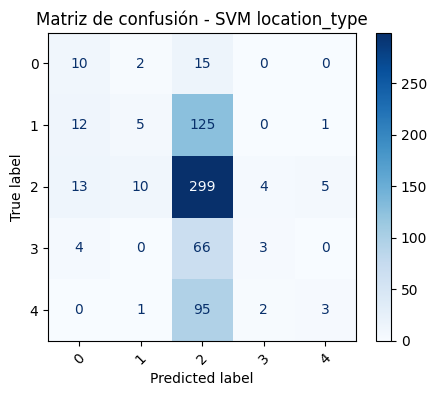


Accuracy: 47.41%
Precisión: 33.98%
Sensibilidad: 27.59%
F1-score: 22.70%


In [ ]:
# SVM
metricas_svm = evaluar_clasificacion(
    y_pred_C1,
    Y_loc_val,
    'SVM location_type'
)


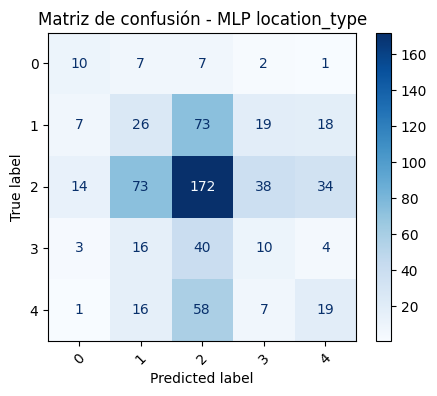


Accuracy: 35.11%
Precisión: 26.94%
Sensibilidad: 27.94%
F1-score: 27.23%


In [ ]:
# MLP
metricas_mlp = evaluar_clasificacion(
    y_pred_C2,
    Y_loc_val,
    'MLP location_type'
)


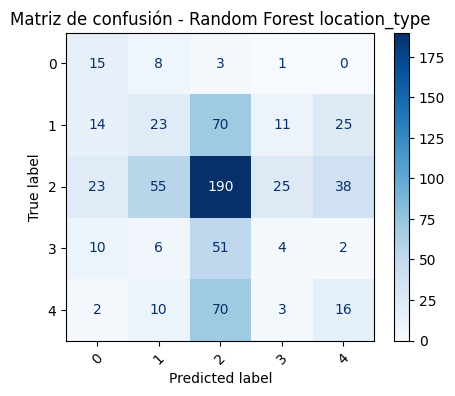


Accuracy: 36.74%
Precisión: 24.86%
Sensibilidad: 30.07%
F1-score: 25.86%


In [ ]:
# Random Forest
metricas_mlp = evaluar_clasificacion(
    y_pred_C3,
    Y_loc_val,
    'Random Forest location_type'
)

 ##### Estado del sujeto al ser encontrado

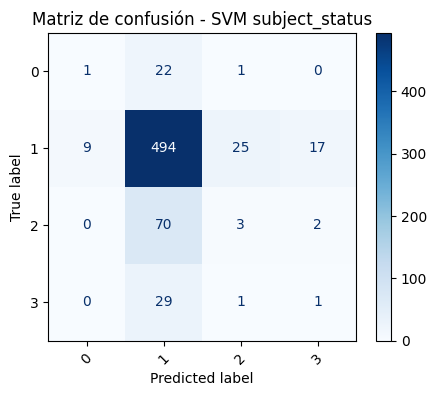


Accuracy: 73.93%
Precisión: 26.33%
Sensibilidad: 25.51%
F1-score: 25.17%


In [ ]:
# SVM
metricas_svm = evaluar_clasificacion(
    y_predsta_C1,
    Y_sta_val,
    'SVM subject_status'
)


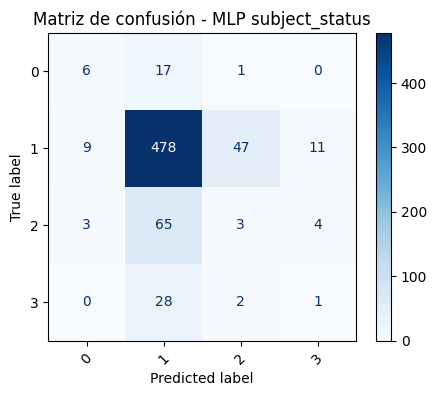


Accuracy: 72.30%
Precisión: 31.63%
Sensibilidad: 29.98%
F1-score: 30.47%


In [ ]:
# MLP
metricas_mlp = evaluar_clasificacion(
    y_predsta_C2,
    Y_sta_val,
    'MLP subject_status'
)


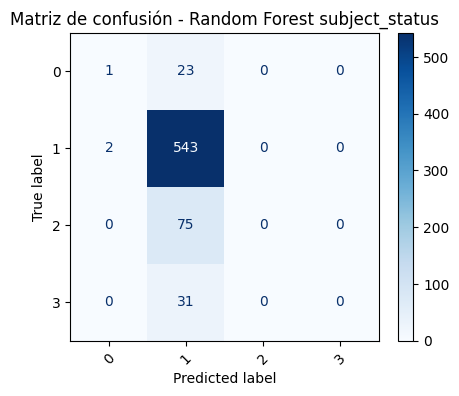


Accuracy: 80.59%
Precisión: 28.53%
Sensibilidad: 25.95%
F1-score: 24.16%


In [ ]:
# Random Forest
metricas_mlp = evaluar_clasificacion(
    y_predsta_C3,
    Y_sta_val,
    'Random Forest subject_status'
)

##### **Conclusiones de las clasificaciones**
Los resultados globales de los modelos de clasificación muestran un patrón claro: ninguno de los algoritmos probados —ni SVM, ni MLP, ni Random Forest— consigue un rendimiento sólido en términos de precisión, sensibilidad o F1‑score (que ronda entre el 25-35%), incluso cuando el accuracy parece moderadamente aceptable (alrededor del 72-80%) en algunos casos. Esto indica que los modelos no están logrando capturar patrones consistentes que permitan diferenciar adecuadamente las clases, especialmente en tareas como tipo de localización, donde el F1‑score cae por debajo del 30% en todos los casos. Aunque se aplicaron técnicas de balanceo como SMOTE para intentar compensar la desigual distribución de clases, los resultados apenas variaron, lo que sugiere que el desbalance no es el principal problema.

La explicación más probable es que el problema reside en la naturaleza del propio dataset. Como los datos se generaron mediante herramientas de inteligencia artificial (con consignas básicas en función de la información disponible en Lost Person Behaviour), es posible que las relaciones entre variables no sean lo suficientemente ricas, realistas o diferenciadas como para que los modelos aprendan patrones útiles. Los modelos de machine learning dependen completamente de la calidad y estructura de los datos: si las clases están solapadas, si las variables no aportan información discriminativa o si existe ruido en las etiquetas, el rendimiento se verá limitado independientemente del algoritmo utilizado. Esto encaja con el hecho de que incluso modelos robustos como Random Forest o redes neuronales no han logrado mejoras significativas.

También es posible que el dataset requiera una limpieza más profunda o una ingeniería de características más elaborada. Variables categóricas con demasiados niveles, valores inconsistentes, falta de normalización o ausencia de variables realmente relevantes pueden dificultar la separación entre clases. En este contexto, los modelos no fallan por su diseño, sino porque los datos no contienen suficiente señal para permitir una clasificación fiable. En conjunto, los resultados sugieren que, más que seguir ajustando modelos, sería recomendable revisar la calidad del dataset, mejorar su coherencia interna o incluso replantear su generación para obtener patrones más diferenciados y representativos.

In [ ]:
# Caso de ejemplo predicción.

#X_test = test_df[X_cols]

subject = X_test.iloc[[1]]

# Mejor modelo
modelo_reg= model_R3 # KNN (k=15)
modelo_clas_loc = model_C1 # SVC
modelo_clas_sta = model_sta_C3 # Random Forest

# Predicción con mejor modelo de regresión
[[distancia, elevacion, h_movilidad]] = modelo_reg.predict(subject)
[pred_loc_s1] = modelo_clas_loc.predict(subject)
[pred_sta_s1] = modelo_clas_sta.predict(subject)


In [ ]:
display(subject)
print('Distancia recorrida (km): ' + str(distancia))
print('Elevación recorrida (m): ' + str(elevacion))
print('Horas de movilidad (h): '+ str(h_movilidad))

print('Predicción del tipo de localización más probable: ' + pred_loc_s1)
print('Predicción del estado del sujeto más probable: ' + pred_sta_s1)

,tipology,category,missing_duration,adult,sex,height,weight,physical_level,physical_constitution,disability,substance_abuse,hearing_problems,visual_problems,age,climate_type,disappearance_zone,disappearance_terrain
0,involuntary,dementia (alzheimer),16.04,1,female,1.66,56.5,sedentary,slim,none,none,none,contact lenses,84,temperate,natural_or_rural,mountain


Distancia recorrida (km): 1.114
Elevación recorrida (m): -75.86666666666666
Horas de movilidad (h): 8.272666666666668
Predicción del tipo de localización más probable: structures
Predicción del estado del sujeto más probable: healthy


In [ ]:
# Datos de un sujeto de prueba al que se le ha aplicado el modelo de predicción.
'''
import pandas as pd

subject = pd.DataFrame([{
    "tipology": "involuntary",
    "category": "dementia (alzheimer)",
    "missing_duration": 16.04,
    "adult": 1,
    "sex": "female",
    "height": 1.66,
    "weight": 56.5,
    "physical_level": "sedentary",
    "physical_constitution": "slim",
    "disability": "none",
    "substance_abuse": "none",
    "hearing_problems": "none",
    "visual_problems": "contact lenses",
    "age": 84,
    "climate_type": "temperate",
    "disappearance_zone": "natural_or_rural",
    "disappearance_terrain": "mountain",
}])

distancia = 1.114
elevacion = -75.86666666666666
h_movilidad = 8.272666666666668
pred_loc_s1 = "structures"
pred_sta_s1 = "healthy"
'''


In [ ]:
# Se van a tener en cuenta factores específicos para cada categoría de sujeto.
df_behavior = pd.read_csv("/content/drive/MyDrive/TFM/data/category_behavior_factors.csv")

display(df_behavior)

,category,spatial_orientation,path_following,obstacle_overcoming,mobility,directional_persistence
0,dementia (alzheimer),0.15,0.70,0.20,0.30,0.20
1,authistic,0.45,0.50,0.50,0.60,0.70
2,intellectual disability,0.40,0.65,0.45,0.50,0.45
3,mental illness,0.35,0.55,0.55,0.65,0.35
4,child 1-3,0.10,0.20,0.15,0.20,0.15
5,child 4-6,0.20,0.25,0.25,0.35,0.20
6,child 7-9,0.35,0.35,0.40,0.50,0.35
7,child 10-12,0.50,0.50,0.50,0.65,0.50
8,child 13-15,0.70,0.60,0.65,0.80,0.65
9,walker/hiker,0.85,0.90,0.75,0.80,0.85


In [ ]:

# Factores relativos a la categoría específica del sujeto de prueba:
categoria = subject['category'].iloc[0]
factores = df_behavior[df_behavior["category"] == categoria].iloc[0]

factores

,0
category,dementia (alzheimer)
spatial_orientation,0.15
path_following,0.7
obstacle_overcoming,0.2
mobility,0.3
directional_persistence,0.2


In [ ]:
factores

,0
category,dementia (alzheimer)
spatial_orientation,0.15
path_following,0.7
obstacle_overcoming,0.2
mobility,0.3
directional_persistence,0.2


## 4. Definición un pequeño mapa

In [ ]:
'''
Se va a diseñar un pequeño mapa simulado de una zona.


'''

In [ ]:
# Necesario para trabajar con los mapas de IGN: https://centrodedescargas.cnig.es/CentroDescargas/detalleArchivo?sec=12408292
!apt-get install -y libgdal-dev gdal-bin
#!pip install rasterio geopandas shapely owslib


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgdal-dev is already the newest version (3.8.4+dfsg-1~jammy0).
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 3 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 1s (4,496 kB/s)
Selecting previously un

In [ ]:
!pip install rasterio geopandas shapely


In [ ]:
# Si el mapa lo tengo en algún archivo propio del ordenador.
#from google.colab import files
#uploaded = files.upload()

In [ ]:
# Información para el recorte en:
import geopandas as gpd
from shapely.geometry import box
import math

lat = 42.12670907
lon = -3.77644781

# Distancia deseada alrededor del punto
km = 20

# Conversión correcta
deg_lat = km / 111
deg_lon = km / (111 * math.cos(math.radians(lat)))

bbox = box(lon - deg_lon, lat - deg_lat,
           lon + deg_lon, lat + deg_lat)

gdf = gpd.GeoDataFrame({"geometry":[bbox]}, crs="EPSG:4326")


In [ ]:
# Recortar y guardar recorte
import rasterio
import matplotlib.pyplot as plt
from rasterio.mask import mask

raster_path = "/content/drive/MyDrive/TFM/data/MP200_Burgos_2024.tif"

with rasterio.open(raster_path) as src:
    gdf_proj = gdf.to_crs(src.crs)  # reproyectar bbox al CRS del raster
    out_img, out_transform = mask(src, gdf_proj.geometry, crop=True)
    out_meta = src.meta.copy()

# Actualizar metadatos del nuevo raster
out_meta.update({
    "height": out_img.shape[1],
    "width": out_img.shape[2],
    "transform": out_transform
})

# Guardar el recorte
with rasterio.open("recorte2_40km.tif", "w", **out_meta) as dest:
    dest.write(out_img)

print("Recorte generado correctamente")


NameError: name 'gdf' is not defined

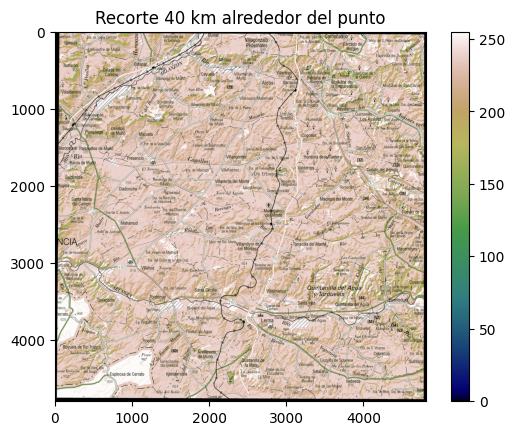

In [ ]:
# Mostrar recorte
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/content/drive/MyDrive/TFM/data/recorte3_40km.tif") as src:
    recorte = src.read(1)

plt.imshow(recorte, cmap="gist_earth")
plt.colorbar()
plt.title("Recorte 40 km alrededor del punto")
plt.show()

In [ ]:
# Recortar el mapa para obtener un mapa de 40x40 km, para que no sea demasiado grande para trabajar con él.

## 5. Ejecución modelo Monte Carlo

In [ ]:
# En base a un resultado de los parámetros obtenidos de la predicción
'''
Distancia = 6.1 km
Elevación = 450 m
Movilidad = 8.2 h

P(location_type)
P(scenario)
P(status)
'''

###### PROBARRRRRRRRRR #####

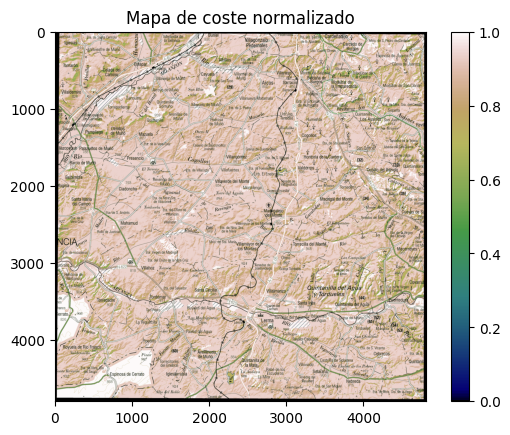

In [ ]:
# FUERAAAA

# Cargar el recorte y preparar la matriz de coste
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("/content/drive/MyDrive/TFM/data/recorte3_40km.tif") as src:
    raster = src.read(1)
    nodata = src.nodata

# pasar a float y manejar nodata
coste = raster.astype(float)
if nodata is not None:
    coste[coste == nodata] = np.nan

# normalizar entre 0 y 1 (altitud como coste)
min_val = np.nanmin(coste)
max_val = np.nanmax(coste)
coste = (coste - min_val) / (max_val - min_val)

plt.imshow(coste, cmap="gist_earth")
plt.colorbar()
plt.title("Mapa de coste normalizado")
plt.show()


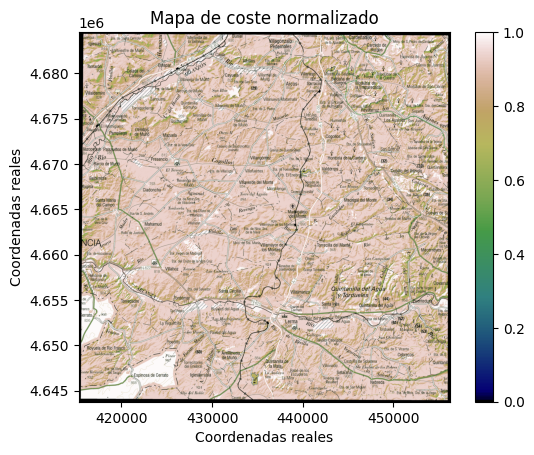

Text(0, 0.5, 'km')

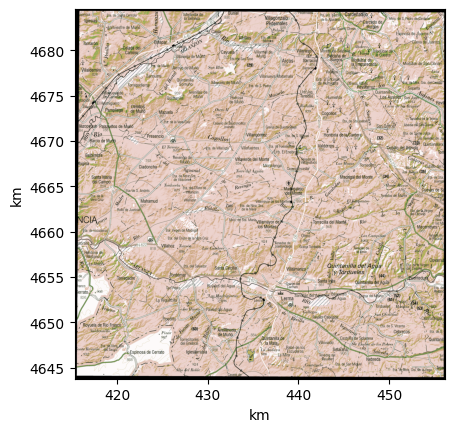

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("/content/drive/MyDrive/TFM/data/recorte3_40km.tif") as src:
    raster = src.read(1)
    nodata = src.nodata
    bounds = src.bounds
    transform = src.transform

# pasar a float y manejar nodata
coste = raster.astype(float)
if nodata is not None:
    coste[coste == nodata] = np.nan

# normalizar entre 0 y 1
min_val = np.nanmin(coste)
max_val = np.nanmax(coste)
coste = (coste - min_val) / (max_val - min_val)

# límites reales del ráster
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

plt.imshow(
    coste,
    cmap="gist_earth",
    extent=extent,
    origin="upper"
)

plt.colorbar()
plt.xlabel("Coordenadas reales")
plt.ylabel("Coordenadas reales")
plt.title("Mapa de coste normalizado")
plt.show()

extent_km = [
    bounds.left / 1000,
    bounds.right / 1000,
    bounds.bottom / 1000,
    bounds.top / 1000
]

plt.imshow(coste, cmap="gist_earth", extent=extent_km, origin="upper")
plt.xlabel("km")
plt.ylabel("km")



**Flujo general para obtener costes combinado**
1. Leer el GeoTIFF y guardar la altitud normalizada como coste_altitud (solo para visualización).
2. Calcular derivadas del DEM: pendiente y orientación.
3. Calcular NDVI si el raster tiene bandas RED y NIR.
4. Rasterizar/red de caminos (si tienes shapefile) y calcular distancia euclidiana a caminos.
5. Extraer hidrología básica (acumulación de flujo) para identificar ríos/valle.
6. Crear máscaras de obstáculos (agua profunda, pendientes extremas, vegetación impenetrable).
7. Normalizar cada capa a 0–1 y combinar con pesos para obtener coste_final.
8. Visualizar: mostrar coste_altitud como antes y coste_final por separado.

In [ ]:
# Celda 1: Imports y parámetros
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from rasterio.features import rasterize
import geopandas as gpd
import math

# Rutas
tif_path = "/content/drive/MyDrive/TFM/data/recorte3_40km.tif"

# Función de normalización segura
def norm_safe(arr):
    arr = np.array(arr, dtype=float)
    arr[np.isinf(arr)] = np.nan
    if np.all(np.isnan(arr)):
        return np.zeros_like(arr)
    mn = np.nanmin(arr)
    mx = np.nanmax(arr)
    if mx == mn:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)


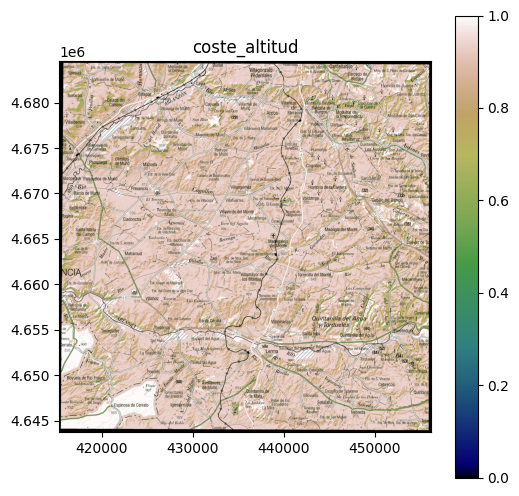

In [ ]:
# Celda 2: Leer DEM y crear coste_altitud para mostrar
with rasterio.open(tif_path) as src:
    profile = src.profile
    transform = src.transform
    crs = src.crs
    bounds = src.bounds
    dem = src.read(1).astype(float)
    nodata = src.nodata
    count_bands = src.count

if nodata is not None:
    dem[dem == nodata] = np.nan

coste_altitud = norm_safe(dem)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

plt.figure(figsize=(6,6))
plt.imshow(coste_altitud, cmap="gist_earth", extent=extent, origin="upper")
plt.title("coste_altitud")
plt.colorbar()
plt.show()


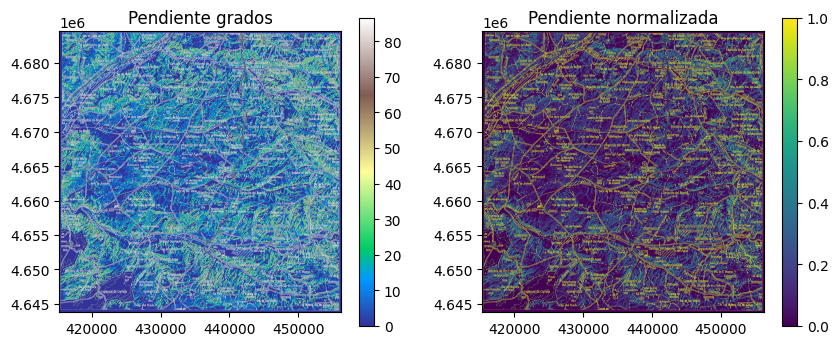

In [ ]:
# Celda 4: Calcular pendiente y orientación
# resolución en metros por píxel
res_x = transform.a
res_y = -transform.e
dx = res_x
dy = res_y

# kernels Horn simplificados
kernel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]]) / (8.0 * dx)
kernel_y = np.array([[1, 2, 1],
                     [0, 0, 0],
                     [-1, -2, -1]]) / (8.0 * dy)

# rellenado simple de NaN con mediana global para evitar propagación en derivadas
dem_filled = dem.copy()
mask_nan = np.isnan(dem_filled)
if np.any(mask_nan):
    dem_filled[mask_nan] = np.nanmedian(dem_filled)

# usar ndimage.convolve (más eficiente que convolve2d)
dzdx = ndimage.convolve(dem_filled, kernel_x, mode='mirror')
dzdy = ndimage.convolve(dem_filled, kernel_y, mode='mirror')

slope_rad = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
slope_deg = np.degrees(slope_rad)
aspect = np.degrees(np.arctan2(dzdy, -dzdx))
aspect = (90.0 - aspect) % 360.0

slope_norm = norm_safe(slope_deg)

# Visualizar pendiente
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(slope_deg, cmap="terrain", extent=extent, origin="upper")
plt.title("Pendiente grados")
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(slope_norm, cmap="viridis", extent=extent, origin="upper")
plt.title("Pendiente normalizada")
plt.colorbar()
plt.show()


/tmp/ipykernel_181/3791031227.py:12: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


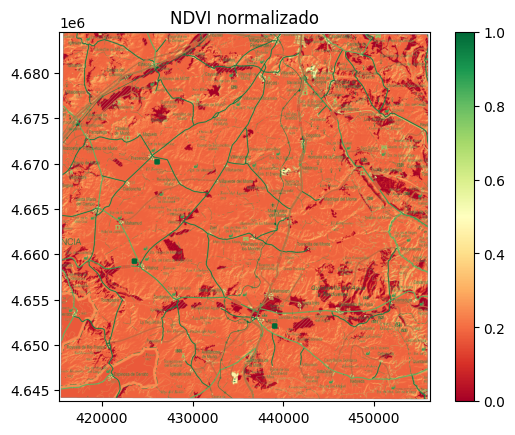

In [ ]:
# Celda 5: Calcular NDVI si hay bandas RED y NIR
ndvi_norm = np.zeros_like(dem) + np.nan
try:
    with rasterio.open(tif_path) as src:
        if src.count >= 4:
            # ajustar índices de banda según tu archivo
            red = src.read(3).astype(float)
            nir = src.read(4).astype(float)
            if nodata is not None:
                red[red == nodata] = np.nan
                nir[nir == nodata] = np.nan
            ndvi = (nir - red) / (nir + red)
            ndvi = np.clip(ndvi, -1, 1)
            ndvi_norm = norm_safe(ndvi)
except Exception:
    ndvi_norm = np.zeros_like(dem) + np.nan

# Visualizar NDVI si existe
if not np.all(np.isnan(ndvi_norm)):
    plt.imshow(ndvi_norm, cmap="RdYlGn", extent=extent, origin="upper")
    plt.title("NDVI normalizado")
    plt.colorbar()
    plt.show()


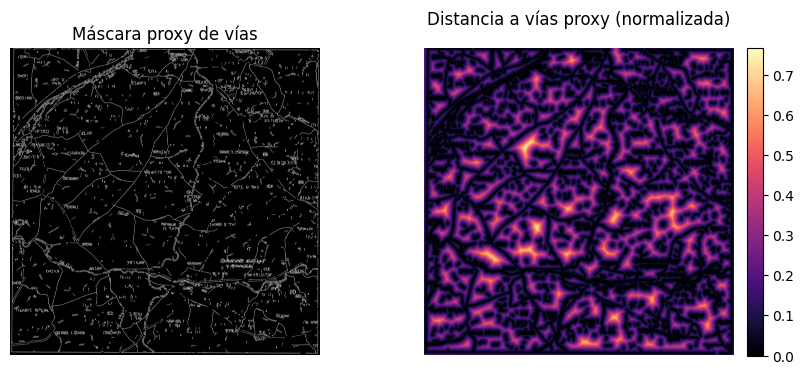

In [ ]:
# Celda 6 optimizada: proxy de vías (ráster-only)
import numpy as np
from scipy.ndimage import gaussian_filter, laplace, binary_opening, binary_closing, label, distance_transform_edt
import matplotlib.pyplot as plt

# 1) Calcular valley_score si no existe
if 'valley_score' not in globals():
    dem_s = gaussian_filter(dem_filled, sigma=3)
    lap = laplace(dem_s)
    lap_inv = -lap
    lap_inv[~np.isfinite(lap_inv)] = np.nan
    lap_min = np.nanmin(lap_inv); lap_max = np.nanmax(lap_inv)
    if lap_max == lap_min:
        valley_score = np.zeros_like(dem)
    else:
        valley_score = (lap_inv - lap_min) / (lap_max - lap_min)
    valley_score = gaussian_filter(valley_score, sigma=1)

# 2) Umbralizar y limpiar (morfología simple)
th = 0.60            # ajusta si hace falta
min_size_px = 200   # ajustar según resolución

candidates = (valley_score >= th)
candidates = binary_opening(candidates, structure=np.ones((3,3)))
candidates = binary_closing(candidates, structure=np.ones((3,3)))

# 3) Etiquetar y conservar solo componentes grandes (ráster)
labeled, ncomp = label(candidates)
mask_clean = np.zeros_like(candidates, dtype=bool)
# vectorizado: contar píxeles por etiqueta con bincount (mucho más rápido que bucle)
labels_flat = labeled.ravel()
counts = np.bincount(labels_flat)
# counts[0] corresponde al fondo
large_labels = np.where(counts >= min_size_px)[0]
# excluir etiqueta 0 (fondo)
large_labels = large_labels[large_labels != 0]
if large_labels.size > 0:
    # crear máscara con etiquetas grandes
    mask_clean = np.isin(labeled, large_labels)
else:
    mask_clean = np.zeros_like(candidates, dtype=bool)

road_raster_proxy = mask_clean.astype('uint8')

# 4) Distancia y normalización
inv = 1 - road_raster_proxy
dist_pix = distance_transform_edt(inv)
pixel_size = (abs(dx) + abs(dy)) / 2.0
dist_m = dist_pix * pixel_size
maxd = 2000.0
dist_m_clipped = np.minimum(dist_m, maxd)
dist_norm_proxy = dist_m_clipped / maxd

# 5) Visualización mínima
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(road_raster_proxy, cmap='gray', extent=extent, origin='upper')
plt.title("Máscara proxy de vías")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dist_norm_proxy, cmap='magma', extent=extent, origin='upper')
plt.title("Distancia a vías proxy (normalizada)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()


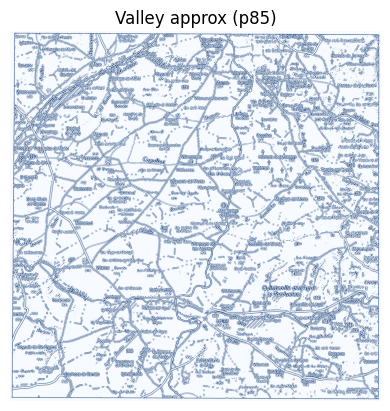

In [ ]:
# Celda 7:Hidrología aproximada y opción D8
percentil = 85
th_val = np.nanpercentile(valley_score, percentil)
valley_approx = (valley_score >= th_val).astype(float)

plt.imshow(valley_approx, cmap='Blues', extent=extent, origin='upper'); plt.title(f"Valley approx (p{percentil})"); plt.axis('off'); plt.show()



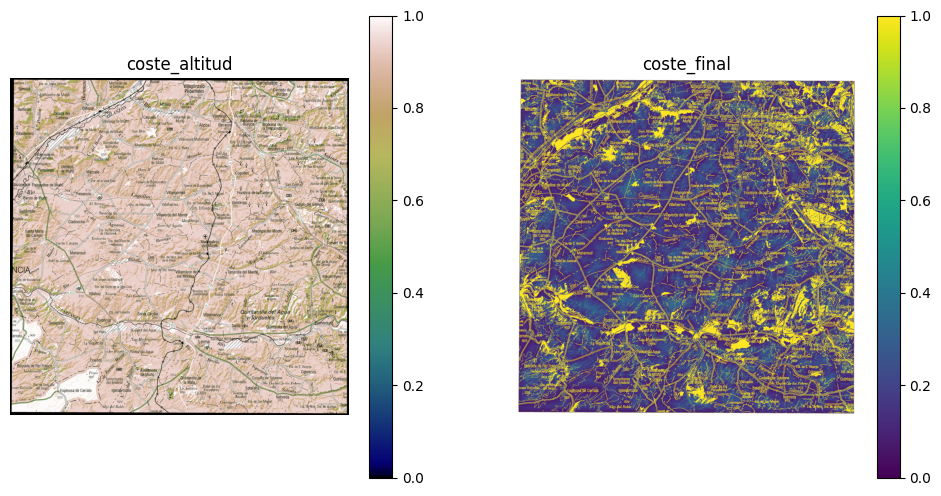

In [ ]:
# Celda 8: Combinar capas en coste_final
# Normalizar capas (si son NaN se convierten a 0 neutro)
slope_n = norm_safe(slope_deg)
ndvi_n = norm_safe(ndvi_norm) if not np.all(np.isnan(ndvi_norm)) else np.zeros_like(dem)
dist_n = norm_safe(dist_norm_proxy) if 'dist_norm_proxy' in globals() else np.zeros_like(dem)
fa_n = norm_safe(valley_score) if 'valley_score' in globals() else np.zeros_like(dem)

# Pesos de ejemplo
w_slope = 0.45
w_ndvi = 0.2
w_dist = 0.2
w_fa = 0.15
coste_comb = w_slope * slope_n + w_ndvi * ndvi_n + w_dist * dist_n + w_fa * (1 - fa_n)

# Máscaras de obstáculos
pendiente_inaccesible = (slope_deg > 45).astype(float)
agua_mask = ((ndvi_n < 0.05) & (fa_n > 0.5)).astype(float)
obstaculos = np.maximum(pendiente_inaccesible, agua_mask)
coste_comb[obstaculos == 1] = 1.0
coste_comb[np.isnan(dem)] = np.nan

coste_final = norm_safe(coste_comb)

# Visualizar
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(coste_altitud, cmap="gist_earth", extent=extent, origin="upper"); plt.title("coste_altitud"); plt.axis('off')
plt.colorbar()
plt.subplot(1,2,2); plt.imshow(coste_final, cmap="viridis", extent=extent, origin="upper"); plt.title("coste_final"); plt.axis('off');
plt.colorbar()
plt.show()

# Guardar resultado
# np.save("/tmp/coste_final.npy", coste_final)
# Para guardar GeoTIFF se puede usar rasterio.open with profile actualizado


In [ ]:
# Para guardar el coste final y otra info y no tener que volver a ejecutar todo lo relativo al mapa.
#np.savetxt("/content/drive/MyDrive/TFM/data/coste_final.txt", coste_final)
#np.savetxt("/content/drive/MyDrive/TFM/data/dist_norm_proxy.txt", dist_norm_proxy)
#np.savetxt("/content/drive/MyDrive/TFM/data/road_raster_proxy.txt", road_raster_proxy)


# Para cargar el coste final:
coste_final = np.loadtxt("/content/drive/MyDrive/TFM/data/coste_final.txt")
dist_norm_proxy = np.loadtxt("/content/drive/MyDrive/TFM/data/dist_norm_proxy.txt")
road_raster_proxy = np.loadtxt("/content/drive/MyDrive/TFM/data/road_raster_proxy.txt")



In [ ]:
#np.savetxt("/content/drive/MyDrive/TFM/data/dist_norm_proxy.txt", dist_norm_proxy)
np.savetxt("/content/drive/MyDrive/TFM/data/road_raster_proxy.txt", road_raster_proxy)

**ALGORITMO MONTECARLO BÁSICO**

1. **Punto de partida**. Se elige una casilla inicial en el mapa (por ejemplo, el centro).
2. **Mirar alrededor**. En cada paso el agente mira las casillas que están justo alrededor suyo (hasta 8 casillas: arriba, abajo, izquierda, derecha y las 4 diagonales).
3. **Valorar cada casilla**. Cada casilla tiene un número que indica lo “fácil” o “difícil” que es pasar por ahí (coste). Cuanto menor sea ese número, más atractiva es la casilla.
4. **Elegir con probabilidad**. El agente no siempre va a la casilla más fácil; en vez de eso, elige una casilla entre las disponibles dando más probabilidad a las más fáciles. Es como si tirara una moneda trucada donde las caras más favorables salen con más frecuencia.
5. **Repetir**. Se repite ese proceso paso a paso hasta completar un número de pasos o hasta que no haya casillas válidas.
6. **Repetir con nuevos agentes**. Se generan cientos de paseos iguales en reglas pero distintos en detalle. Al superponerlos se ve por dónde pasan más frecuentemente: esas zonas son las más probables.



In [ ]:
# Como la resolucion es 8,46 x 8,46.
# Por ejemplo: necesitamos unos 720 pasos para que el camino mida ~6.1 km.
# FUNCION MONTE CARLO BÁSICO CON RESOLUCION REAL:
import random

vecinos = [(-1,-1), (-1,0), (-1,1),
           (0,-1), (0,0), (0,1),
           (1,-1), (1,0), (1,1)]

def camino_montecarlo(coste, inicio, distancia_km):
    resolucion_m = 8.466565566410896
    pasos = int((distancia_km * 1000) / resolucion_m)

    i, j = inicio
    camino = [(i, j)]

    for _ in range(pasos):
        opciones = []
        pesos = []

        for di, dj in vecinos:
            ni, nj = i + di, j + dj
            if 0 <= ni < coste.shape[0] and 0 <= nj < coste.shape[1]:
                c = coste[ni, nj]
                if not np.isnan(c):
                    opciones.append((ni, nj))
                    pesos.append(1 / (1 + c))

        if not opciones:
            break

        idx = random.choices(range(len(opciones)), weights=pesos)[0]
        i, j = opciones[idx]
        camino.append((i, j))

    return camino


**ALGORITMO DE MONTECARLO AVANZADO**

Esta nueva versión del modelo Montecarlo combina atracción al objetivo, preferencia por vías, capacidad para superar obstáculos, movilidad (quedarse quieto) y persistencia direccional, usando coste_final y la proxy de vías (road_raster_proxy, dist_norm_proxy). El método es un biased random walk con pesos multiplicativos y normalización.

Principios:
1. **Misma base de probabilidad**: $𝑤_b = 1/(1+coste)$
2. **Atracción al objetivo**: factor exponencial según distancia euclidiana al objetivo; mayor orientacion espacial, mayor influencia.
3. **Path following**: usar dist_norm_proxy (0 cerca de vias, 1 lejos) para favorecer celdas próximas a vías. Mayor path following, mayor peso a celdas cercanas.
4. **Obstacle overcoming**: si la celda es obstáculo (coste cercano a 1 o pendiente alta), reducir su penalización según obstacle_overcoming.
5. **Movilidad**: si mobility es baja, aumentar la probabilidad de elegir el vecino.
6. **Persistencia direccional**: si la dirección anterior existe, multiplicar el peso de la celda que mantiene la misma dirección por $1+k·directionalPersistence$.


In [ ]:
# MONTECARLO AVANZADO
import numpy as np
import random
import math

vecinos = [(-1,-1), (-1,0), (-1,1),
           (0,-1), (0,0), (0,1),
           (1,-1), (1,0), (1,1)]

def camino_montecarlo_avanzado(coste, inicio, distancia_km,
                               target=None,
                               spatial_orientation=0.5,
                               path_following=0.5,
                               obstacle_overcoming=0.5,
                               mobility=0.5,
                               directional_persistence=0.5,
                               resolucion_m=8.466565566410896):
    pasos = int((distancia_km * 1000) / resolucion_m)
    i, j = inicio
    camino = [(i, j)]
    prev_move = None

    # precomputar coordenadas de celdas si hay target
    if target is not None:
        tx, ty = target

    for _ in range(pasos):
        opciones = []
        pesos = []

        for di, dj in vecinos:
            ni, nj = i + di, j + dj
            if 0 <= ni < coste.shape[0] and 0 <= nj < coste.shape[1]:
                c = coste[ni, nj]
                if np.isnan(c):
                    continue

                # peso base inverso al coste
                w = 1.0 / (1.0 + c)

                # 1) Atracción al objetivo
                if target is not None and spatial_orientation > 0:
                    d_curr = math.hypot(i - tx, j - ty)
                    d_next = math.hypot(ni - tx, nj - ty)
                    # si acercarse reduce distancia, favorecerlo
                    delta = d_curr - d_next
                    # escala suave: exp de la mejora
                    w *= math.exp(spatial_orientation * (delta / (1 + d_curr)))

                # 2) Path following (usar dist_norm_proxy si existe en globals)
                if 'dist_norm_proxy' in globals() and path_following > 0:
                    # dist_norm_proxy: 0 cerca de vías, 1 lejos
                    prox = 1.0 - dist_norm_proxy[ni, nj]  # 1 = muy cerca
                    w *= (1.0 + path_following * prox)

                # 3) Obstacle overcoming: si coste alto (ej. >0.9) penaliza menos si capacidad alta
                if c >= 0.9:
                    w *= (0.1 + 0.9 * obstacle_overcoming)

                # 4) Movilidad: favorecer quedarse quieto si mobility baja
                if (di, dj) == (0,0):
                    # mobility en [0,1], si baja -> aumentar w_stay
                    w *= (1.0 + (1.0 - mobility) * 5.0)

                # 5) Persistencia direccional
                if prev_move is not None and directional_persistence > 0:
                    if (di, dj) == prev_move:
                        w *= (1.0 + directional_persistence * 2.0)

                opciones.append((ni, nj))
                pesos.append(max(w, 1e-12))

        if not opciones:
            break

        # normalizar y elegir
        pesos = np.array(pesos, dtype=float)
        pesos /= pesos.sum()
        idx = np.random.choice(len(opciones), p=pesos)
        ni, nj = opciones[idx]

        prev_move = (ni - i, nj - j)
        i, j = ni, nj
        camino.append((i, j))

    return camino


In [ ]:
'''# Definir vecinos y función de camino Montecarlo
import random

# 8 vecinos (movimiento en todas direcciones)
vecinos = [(-1,-1), (-1,0), (-1,1),
           (0,-1),  (0,0),          (0,1),
           (1,-1),  (1,0),  (1,1)]

def camino_montecarlo(coste, inicio, pasos=300):
    # El inicio será el centro del mapa
    i, j = inicio

    # Lista que recogerá los pasos del camino total
    camino = [(i, j)]

    # Se recorren todos los pasos, que luego se modificarán en función del valor predicho en distancia.
    for _ in range(pasos):
        opciones = []
        pesos = []

        # Para todas las coordenadas de celdas vecinas posibles
        for di, dj in vecinos:
            # Celda vecina
            ni, nj = i + di, j + dj

            # Si la celda vecina se encuentra dentro de la matriz (mapa)
            if 0 <= ni < coste.shape[0] and 0 <= nj < coste.shape[1]:
                # Se añade el coste de esa celda en la lista de opciones.
                c = coste[ni, nj]
                if not np.isnan(c):
                    opciones.append((ni, nj))
                    # menor coste → mayor probabilidad
                    pesos.append(1 / (1 + c))

        if not opciones:
            break
        # Se elige una opción al aleatoria ponderada en función de los pesos o coste de cada opción.
        idx = random.choices(range(len(opciones)), weights=pesos)[0]
        i, j = opciones[idx]
        # Se añade esa opción aleatoria ponderada al camino.
        camino.append((i, j))

    return camino
'''

**Pruebas con MonteCarlo Básico**

In [ ]:
# Elegir un punto de inicio y lanzar varios caminos,
# en este caso el centro del recorte que son nuestras coordenadas objetivo, que
# en un futuro coincidirán con las coordenadas de la última posición conocida de la persona desaparecida.
h, w = coste.shape
inicio = (h // 2, w // 2)

todos_caminos = []
for _ in range(200):  # 200 caminos
    c = camino_montecarlo(coste_final, inicio=inicio, distancia_km=distancia)
    todos_caminos.append(c)


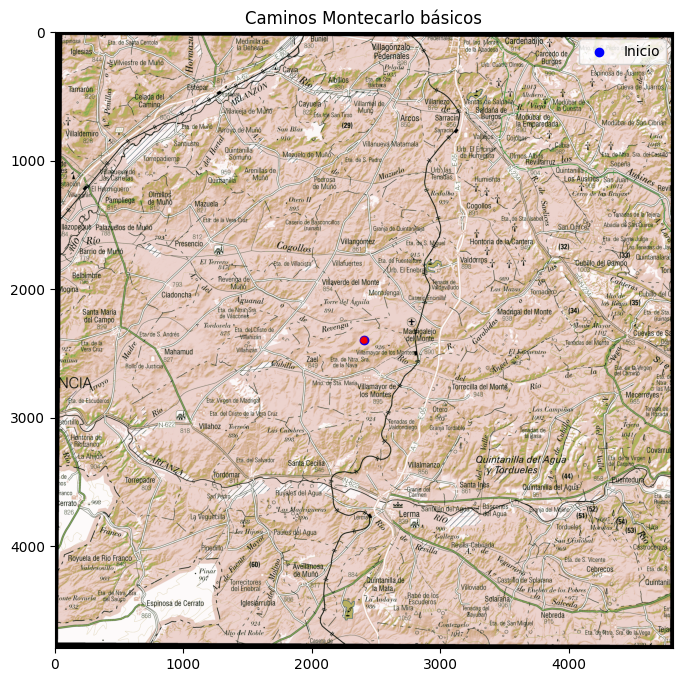

In [ ]:
# Visualizar los caminos sobre el mapa
plt.figure(figsize=(8,8))
plt.imshow(coste, cmap="gist_earth")

for c in todos_caminos:
    xs = [p[1] for p in c]
    ys = [p[0] for p in c]
    plt.plot(xs, ys, color="red", alpha=0.1)

plt.scatter([inicio[1]], [inicio[0]], color="blue", label="Inicio")
plt.legend()
plt.title("Caminos Montecarlo básicos")
plt.show()


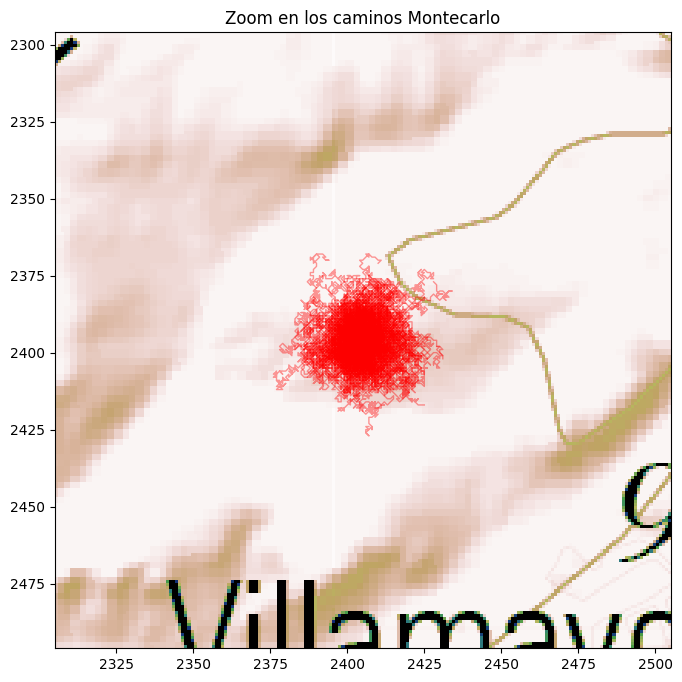

In [ ]:
# Zoom alrededor del punto
zoom = 100  # píxeles alrededor del inicio

i0, j0 = inicio
i_min, i_max = max(0, i0 - zoom), min(coste.shape[0], i0 + zoom)
j_min, j_max = max(0, j0 - zoom), min(coste.shape[1], j0 + zoom)

plt.figure(figsize=(8,8))
plt.imshow(coste[i_min:i_max, j_min:j_max], cmap="gist_earth",
           extent=[j_min, j_max, i_max, i_min])

for c in todos_caminos:
    xs = [p[1] for p in c]
    ys = [p[0] for p in c]
    plt.plot(xs, ys, color="red", alpha=0.4, linewidth=1.0)

plt.scatter([inicio[1]], [inicio[0]], color="blue", s=30)
plt.title("Zoom en los caminos Montecarlo")
plt.show()


In [ ]:
longitudes = [len(c) for c in todos_caminos]
print("Longitud media:", sum(longitudes)/len(longitudes))
print("Longitud mínima:", min(longitudes))
print("Longitud máxima:", max(longitudes))


Longitud media: 801.0
Longitud mínima: 801
Longitud máxima: 801


In [ ]:
# Medición de los pasos en mi mapa:
with rasterio.open("recorte_40km.tif") as src:
    transform = src.transform
    res_x = transform[0]
    res_y = -transform[4]  # suele ser negativo
    print("Resolución:", res_x, res_y)


Resolución: 8.466565566410896 8.466565566410896


In [ ]:
# Generación de caminos
'''
h, w = coste.shape
inicio = (h // 2, w // 2)

todos_caminos = []
for _ in range(200):
    c = camino_montecarlo(coste, inicio=inicio,
                                    distancia_km=6.1,
                                    resolucion_m=8.466565566410896)
    todos_caminos.append(c)
'''


In [ ]:
# COmprobar la distancia real de los caminos:
distancias = [ (len(c)-1) * 8.466565566410896 / 1000 for c in todos_caminos ]

print("Distancia media:", sum(distancias)/len(distancias), "km")
print("Mínima:", min(distancias), "km")
print("Máxima:", max(distancias), "km")


Distancia media: 6.095927207815846 km
Mínima: 6.095927207815846 km
Máxima: 6.095927207815846 km


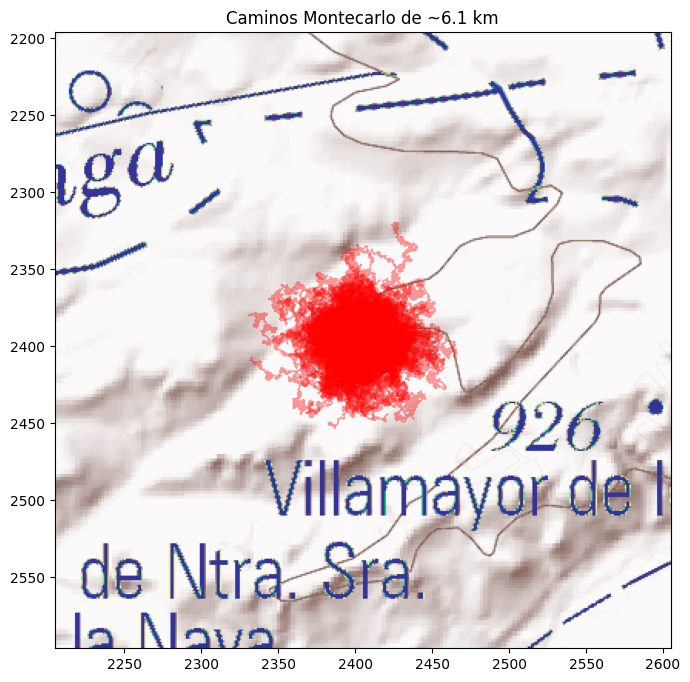

In [ ]:
# Visualización con Zoom
import matplotlib.pyplot as plt

zoom = 200
i0, j0 = inicio
i_min, i_max = i0 - zoom, i0 + zoom
j_min, j_max = j0 - zoom, j0 + zoom

plt.figure(figsize=(8,8))
plt.imshow(coste[i_min:i_max, j_min:j_max], cmap="terrain",
           extent=[j_min, j_max, i_max, i_min])

for c in todos_caminos:
    xs = [p[1] for p in c]
    ys = [p[0] for p in c]
    plt.plot(xs, ys, color="red", alpha=0.4, linewidth=1.2)

plt.scatter([inicio[1]], [inicio[0]], color="blue", s=40)
plt.title("Caminos Montecarlo de ~6.1 km")
plt.show()


**Pruebas con MonteCarlo Avanzado**

In [ ]:
print(factores['spatial_orientation'])

0.15


In [ ]:
# Supuestos: coste_final, road_raster_proxy, dist_norm_proxy ya existen en el entorno
# y la función camino_montecarlo_avanzado está definida tal como te propuse.

import numpy as np
import math

h, w = coste_final.shape
inicio = (h // 2, w // 2)

# Ejemplo de objetivo conocido en coordenadas de índice (fila, columna)
# Puedes elegir otro punto o poner target = None para objetivo desconocido
target = (int(h/2 + 150), int(w/2 + 150))

# Factores del sujeto (ejemplo: persona con Alzheimer)
'''
factors = {
    "spatial_orientation": factores['spatial_orientation'],
    "path_following": factores['path_following'],
    "obstacle_overcoming": factores['obstacle_overcoming'],
    "mobility": factores['mobility'],
    "directional_persistence": factores['directional_persistence']
}'''

factors = {
    "spatial_orientation": 0.85,
    "path_following": 0.90,
    "obstacle_overcoming": 0.75,
    "mobility": 0.80,
    "directional_persistence": 0.85
}

n_sim = 500
distancia_km = 6
resolucion_m = 8.466565566410896

todos_caminos = []
metricas = []  # lista de dicts con métricas por camino

for sim in range(n_sim):
    camino = camino_montecarlo_avanzado(
        coste=coste_final,
        inicio=inicio,
        distancia_km=distancia_km,
        target=target,
        spatial_orientation=factors["spatial_orientation"],
        path_following=factors["path_following"],
        obstacle_overcoming=factors["obstacle_overcoming"],
        mobility=factors["mobility"],
        directional_persistence=factors["directional_persistence"],
        resolucion_m=resolucion_m
    )
    todos_caminos.append(camino)

    # Métricas simples por camino
    pasos = len(camino)
    # distancia final al objetivo en píxeles y en metros aproximados
    if target is not None and pasos > 0:
        last = camino[-1]
        dist_pix = math.hypot(last[0] - target[0], last[1] - target[1])
        pixel_size = resolucion_m
        dist_m = dist_pix * pixel_size
    else:
        dist_m = np.nan

    # porcentaje de pasos sobre proxy de vías (si existe)
    on_road = 0
    on_obstacle = 0
    for (r, c) in camino:
        if 'road_raster_proxy' in globals() and road_raster_proxy[r, c] == 1:
            on_road += 1
        # considerar obstáculo si coste_final cercano a 1 o máscara de obstáculos
        if coste_final[r, c] >= 0.95:
            on_obstacle += 1

    pct_on_road = on_road / pasos if pasos > 0 else 0.0
    pct_on_obstacle = on_obstacle / pasos if pasos > 0 else 0.0

    metricas.append({
        "sim": sim,
        "pasos": pasos,
        "dist_final_m": dist_m,
        "pct_on_road": pct_on_road,
        "pct_on_obstacle": pct_on_obstacle
    })

# Resumen agregado
distancias = [m["dist_final_m"] for m in metricas if not np.isnan(m["dist_final_m"])]
print("Simulaciones:", n_sim)
print("Longitud media pasos:", np.mean([m["pasos"] for m in metricas]))
if len(distancias) > 0:
    print("Distancia media al objetivo (m):", np.mean(distancias))
print("Porcentaje medio pasos en vías:", np.mean([m["pct_on_road"] for m in metricas]))
print("Porcentaje medio pasos en obstáculos:", np.mean([m["pct_on_obstacle"] for m in metricas]))


Simulaciones: 500
Longitud media pasos: 709.0
Distancia media al objetivo (m): 1781.901852945039
Porcentaje medio pasos en vías: 0.0
Porcentaje medio pasos en obstáculos: 0.006719322990126939


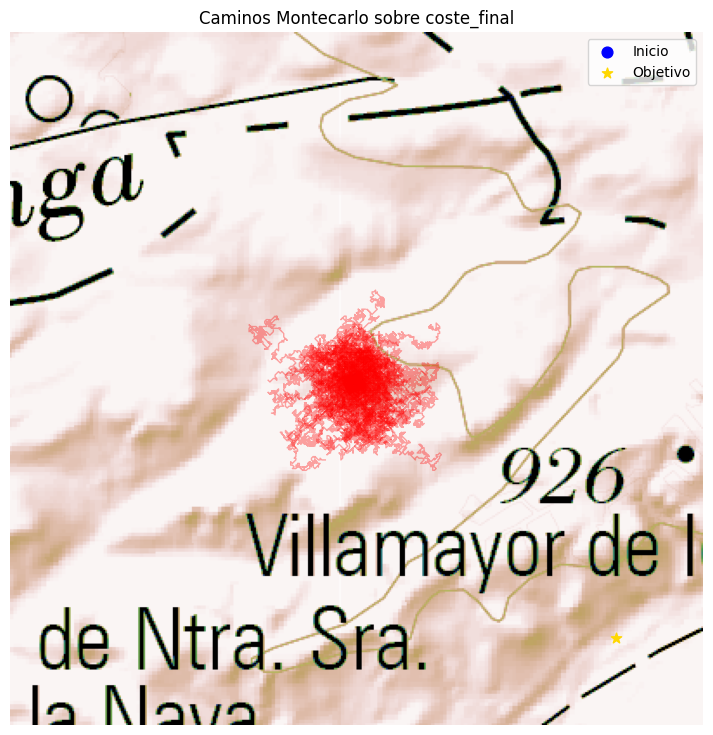

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros
zoom = 200
i0, j0 = inicio
i_min, i_max = max(0, i0 - zoom), min(coste_final.shape[0], i0 + zoom)
j_min, j_max = max(0, j0 - zoom), min(coste_final.shape[1], j0 + zoom)

# Selección de caminos a dibujar para no saturar la figura
n_plot = 50
subset = todos_caminos[:n_plot] if len(todos_caminos) > n_plot else todos_caminos

plt.figure(figsize=(9,9))
# Mostrar coste como fondo
plt.imshow(coste[i_min:i_max, j_min:j_max], cmap="gist_earth",
           extent=[j_min, j_max, i_max, i_min], origin='upper')

# Dibujar caminos
for c in subset:
    xs = [p[1] for p in c]
    ys = [p[0] for p in c]
    plt.plot(xs, ys, color="red", alpha=0.35, linewidth=1.0)

# Inicio y objetivo
plt.scatter([inicio[1]], [inicio[0]], color="blue", s=60, label="Inicio")
if 'target' in globals() and target is not None:
    plt.scatter([target[1]], [target[0]], color="gold", s=60, marker='*', label="Objetivo")

plt.xlim(j_min, j_max)
plt.ylim(i_max, i_min)
plt.title("Caminos Montecarlo sobre coste_final")
plt.legend(loc='upper right')
plt.axis('off')
plt.show()



## 6. Obtención de mapa de calor con las POA y división en cuadrículas.


/tmp/ipykernel_181/1784306963.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


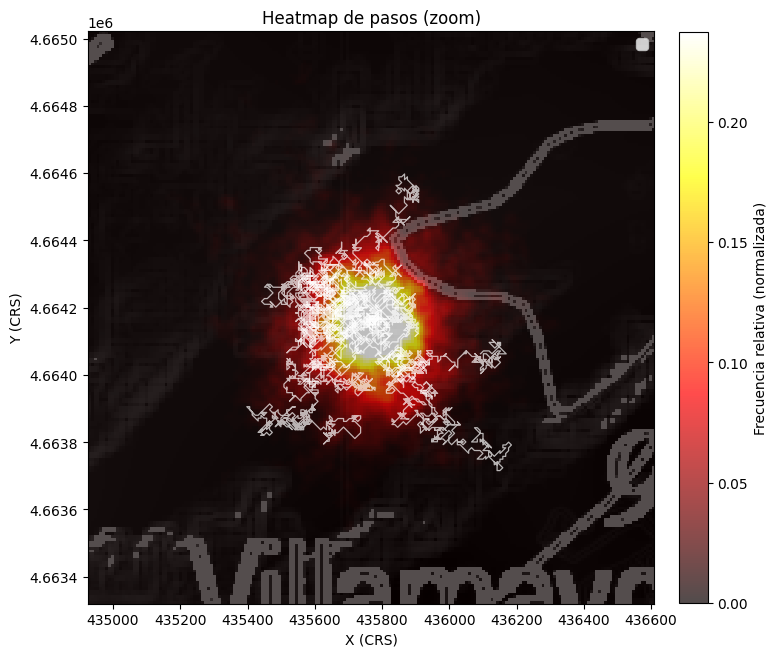

In [ ]:
# Mapa de calor y algunos caminos

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Parámetros de zoom (en píxeles)
zoom_px = 100   # reducir para más zoom (ej. 20, 50, 100)
i0, j0 = inicio
i_min, i_max = max(0, i0 - zoom_px), min(coste_final.shape[0], i0 + zoom_px)
j_min, j_max = max(0, j0 - zoom_px), min(coste_final.shape[1], j0 + zoom_px)

# 1) Acumulador de visitas
acc = np.zeros_like(coste_final, dtype=float)
for c in todos_caminos:
    for (r, col) in c:
        if 0 <= r < acc.shape[0] and 0 <= col < acc.shape[1]:
            acc[r, col] += 1

# 2) Recorte
coste_crop = coste_final[i_min:i_max, j_min:j_max]
acc_crop = acc[i_min:i_max, j_min:j_max]

# 3) Suavizar el acumulador para ver zonas (opcional)
sigma_smooth = 1.0   # 0 = sin suavizado; 1-3 para suavizar
if sigma_smooth > 0:
    acc_smooth = gaussian_filter(acc_crop, sigma=sigma_smooth)
else:
    acc_smooth = acc_crop.copy()

# 4) Normalizar y controlar vmax con percentil para evitar que un píxel domine
acc_norm = acc_smooth / (acc_smooth.max() if acc_smooth.max() > 0 else 1.0)
vmax = np.percentile(acc_norm, 99)   # ajusta percentil si hace falta
vmax = max(vmax, 0.01)               # evitar vmax=0

# 5) Calcular extent en coordenadas CRS usando transform
# top-left: (col=j_min, row=i_min), bottom-right: (col=j_max, row=i_max)
x_min, y_max = transform * (j_min, i_min)
x_max, y_min = transform * (j_max, i_max)
extent_geo = [x_min, x_max, y_min, y_max]   # left, right, bottom, top

# 6) Plot
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(coste_crop, cmap='gray', extent=extent_geo, origin='upper', interpolation='nearest')
im = ax.imshow(acc_norm, cmap='hot', alpha=0.7, extent=extent_geo, origin='upper',
               interpolation='nearest', vmin=0, vmax=vmax)

# 7) Dibujar algunos caminos convertidos a CRS (solo los puntos dentro del recorte)
n_plot = min(10, len(todos_caminos))
for c in todos_caminos[:n_plot]:
    xs, ys = [], []
    for (r, col) in c:
        if i_min <= r < i_max and j_min <= col < j_max:
            x, y = transform * (col + 0.5, r + 0.5)
            xs.append(x); ys.append(y)
    if xs:
        ax.plot(xs, ys, color='white', linewidth=0.9, alpha=0.7)

# 8) Inicio y objetivo en CRS
'''
x0, y0 = transform * (inicio[1] + 0.5, inicio[0] + 0.5)
ax.scatter([x0], [y0], color='cyan', s=60, label='Inicio')
if 'target' in globals() and target is not None:
    tx, ty = transform * (target[1] + 0.5, target[0] + 0.5)
    ax.scatter([tx], [ty], color='yellow', marker='*', s=80, label='Objetivo')
'''
ax.set_title('Heatmap de pasos (zoom)')
ax.set_xlabel('X (CRS)')
ax.set_ylabel('Y (CRS)')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Frecuencia relativa (normalizada)')
plt.show()


### División en cuadrículas y cálculo de POA por celda.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, sqrt
from rasterio.transform import xy

def grid_from_n(n_resp):
    """
    Devuelve el tamaño A de la cuadrícula (A x A) calculado a partir
    del número de responsables n_resp (ceil(sqrt(n_resp))).
    """
    return int(ceil(sqrt(max(1, n_resp))))

def compute_poa_grid(acc_array, i_min, i_max, j_min, j_max, A):
    """
    Divide el recorte acc_array[i_min:i_max, j_min:j_max] en A x A celdas.
    Devuelve lista de celdas con: indices píxel (r0,r1,c0,c1), POA (media),
    área_m2, centroid_pixel (r_c, c_c).
    """
    crop = acc_array[i_min:i_max, j_min:j_max]
    h, w = crop.shape
    # tamaño de cada bloque en píxeles (algunos bloques pueden ser +1)
    base_h = h // A
    base_w = w // A
    rem_h = h % A
    rem_w = w % A

    cells = []
    r0 = 0
    for ai in range(A):
        # distribuir restos en las primeras rem_h filas
        rh = base_h + (1 if ai < rem_h else 0)
        c0 = 0
        for aj in range(A):
            cw = base_w + (1 if aj < rem_w else 0)
            r1 = r0 + rh
            c1 = c0 + cw
            if rh <= 0 or cw <= 0:
                # celda vacía (si A > tamaño)
                poa = 0.0
            else:
                block = crop[r0:r1, c0:c1]
                # si trabajas con frecuencias, puedes normalizar fuera; aquí usamos media
                poa = float(np.nanmean(block)) if np.isfinite(block).any() else 0.0

            # centroid en píxeles relativos al recorte
            r_cent = r0 + rh / 2.0
            c_cent = c0 + cw / 2.0

            cells.append({
                "grid_row": ai,
                "grid_col": aj,
                "r0": int(r0 + i_min),
                "r1": int(r1 + i_min),
                "c0": int(c0 + j_min),
                "c1": int(c1 + j_min),
                "poa": poa,
                "r_cent_rel": r_cent,   # relativo al crop
                "c_cent_rel": c_cent,   # relativo al crop
                "r_cent": r_cent + i_min, # en índices globales
                "c_cent": c_cent + j_min, # en índices globales
                "pixels_h": rh,
                "pixels_w": cw
            })
            c0 = c1
        r0 = r1

    return cells

def compute_area_m2_for_cell(cell, transform):
    """
    Calcula el área en m2 y km2 de la celda usando transform.
    transform.a = pixel width; transform.e = -pixel height (normalmente)
    """
    px_w = transform.a
    px_h = abs(transform.e)
    area_m2 = cell["pixels_h"] * cell["pixels_w"] * px_w * px_h
    area_km2 = area_m2 / 1e6
    return area_m2, area_km2

def centroid_coords(cell, transform):
    """
    Devuelve coordenadas CRS (x,y) del centro de la celda usando transform.
    Usamos el centro del píxel: transform * (col + 0.5, row + 0.5)
    """
    col = cell["c_cent"]
    row = cell["r_cent"]
    # transform expects (col, row)
    x, y = transform * (col + 0.5, row + 0.5)
    return x, y

def assign_responders(cells, n_responders, mode="one_per_cell_then_extra"):
    """
    Asigna n_responders a las celdas según POA.
    Modes:
      - "one_per_cell_then_extra": asigna 1 por celda por orden POA hasta agotar o hasta una por celda,
         si quedan extras reparte proporcionalmente a POA.
      - "proportional": reparte todos los responsables proporcionalmente a POA (puede dar >1 por celda).
    Devuelve lista de celdas con campo 'assigned' (int).
    """
    # ordenar por poa descendente
    cells_sorted = sorted(cells, key=lambda x: x["poa"], reverse=True)
    total_poa = sum(c["poa"] for c in cells_sorted)
    # inicializar
    for c in cells_sorted:
        c["assigned"] = 0

    if mode == "one_per_cell_then_extra":
        # primera pasada: asignar 1 por celda hasta n_responders o hasta agotar celdas
        for c in cells_sorted:
            if n_responders <= 0:
                break
            c["assigned"] += 1
            n_responders -= 1
        # si quedan responsables, repartir por POA proporcional
        if n_responders > 0 and total_poa > 0:
            # calcular fracciones proporcionales
            weights = np.array([c["poa"] for c in cells_sorted], dtype=float)
            weights_sum = weights.sum()
            if weights_sum == 0:
                # repartir uniformemente
                idxs = np.arange(len(cells_sorted))
                for k in range(n_responders):
                    cells_sorted[k % len(cells_sorted)]["assigned"] += 1
            else:
                frac = weights / weights_sum
                extras = np.floor(frac * n_responders).astype(int)
                assigned_extra = extras.sum()
                for idx, e in enumerate(extras):
                    cells_sorted[idx]["assigned"] += int(e)
                # repartir restos uno a uno por orden POA
                rest = n_responders - assigned_extra
                idx = 0
                while rest > 0:
                    cells_sorted[idx]["assigned"] += 1
                    rest -= 1
                    idx = (idx + 1) % len(cells_sorted)
    elif mode == "proportional":
        if total_poa == 0:
            # repartir uniformemente
            base = n_responders // len(cells_sorted)
            rem = n_responders % len(cells_sorted)
            for idx, c in enumerate(cells_sorted):
                c["assigned"] = base + (1 if idx < rem else 0)
        else:
            frac = np.array([c["poa"] for c in cells_sorted], dtype=float) / total_poa
            assigned = np.floor(frac * n_responders).astype(int)
            assigned_sum = assigned.sum()
            for idx, a in enumerate(assigned):
                cells_sorted[idx]["assigned"] = int(a)
            # repartir restos por orden POA
            rest = n_responders - assigned_sum
            idx = 0
            while rest > 0:
                cells_sorted[idx]["assigned"] += 1
                rest -= 1
                idx = (idx + 1) % len(cells_sorted)
    else:
        raise ValueError("mode desconocido")

    # devolver en el orden original (grid_row, grid_col)
    return sorted(cells_sorted, key=lambda x: (x["grid_row"], x["grid_col"]))

def build_grid_and_assign(acc_array, transform, inicio, n_responders=None, A=None,
                          zoom_px=100, mode="one_per_cell_then_extra", use_prob_norm=True):
    """
    Función de alto nivel:
      - si A es None y n_responders dado, calcula A = ceil(sqrt(n_responders))
      - recorta alrededor de inicio con zoom_px
      - calcula celdas, POA, áreas, centroides CRS
      - asigna responsables
    Retorna: cells (lista con info), extent_geo (para plotting), acc_crop, coste_crop
    """
    i0, j0 = inicio
    i_min, i_max = max(0, i0 - zoom_px), min(acc_array.shape[0], i0 + zoom_px)
    j_min, j_max = max(0, j0 - zoom_px), min(acc_array.shape[1], j0 + zoom_px)

    if A is None:
        if n_responders is None:
            raise ValueError("Debes indicar A o n_responders")
        A = grid_from_n(n_responders)

    cells = compute_poa_grid(acc_array, i_min, i_max, j_min, j_max, A)

    # calcular áreas y centroides CRS y poa final
    for c in cells:
        area_m2, area_km2 = compute_area_m2_for_cell(c, transform)
        c["area_m2"] = area_m2
        c["area_km2"] = area_km2
        cx, cy = centroid_coords(c, transform)
        c["centroid_x"] = cx
        c["centroid_y"] = cy

    # si acc_array es conteo, y quieres probabilidad por píxel, normaliza
    if use_prob_norm:
        # normalizar POA para que sum(celda_area * poa) sea 1 si se desea probabilidad total
        # aquí normalizamos las poa entre 0 y 1 por simplicidad
        poas = np.array([c["poa"] for c in cells], dtype=float)
        maxp = poas.max() if poas.max() > 0 else 1.0
        for c in cells:
            c["poa_norm"] = c["poa"] / maxp
    else:
        for c in cells:
            c["poa_norm"] = c["poa"]

    # asignar responsables
    if n_responders is not None:
        assigned_cells = assign_responders(cells, n_responders, mode=mode)
    else:
        assigned_cells = cells

    # extent en CRS para plotting del recorte
    x_min, y_max = transform * (j_min, i_min)
    x_max, y_min = transform * (j_max, i_max)
    extent_geo = [x_min, x_max, y_min, y_max]

    return assigned_cells, extent_geo, (i_min, i_max, j_min, j_max)

def plot_grid_assignments(assigned_cells, extent_geo, acc_array, transform, crop_idx, show_labels=True):
    """
    Dibuja el recorte de coste_final o acc y superpone la cuadrícula con POA y asignaciones.
    crop_idx = (i_min, i_max, j_min, j_max)
    """
    i_min, i_max, j_min, j_max = crop_idx
    coste_crop = coste_final[i_min:i_max, j_min:j_max]
    fig, ax = plt.subplots(figsize=(9,9))
    ax.imshow(coste_crop, cmap='gray', extent=extent_geo, origin='upper', interpolation='nearest')

    # dibujar rectángulos de cada celda
    for c in assigned_cells:
        # calcular esquina en CRS
        x0, y0 = transform * (c["c0"], c["r0"])  # top-left
        x1, y1 = transform * (c["c1"], c["r1"])  # bottom-right
        left, right = x0, x1
        top, bottom = y0, y1
        width = right - left
        height = bottom - top
        rect = plt.Rectangle((left, top), width, height, edgecolor='cyan', facecolor='none', linewidth=1.0)
        ax.add_patch(rect)
        if show_labels:
            # etiqueta con POA normalizada y asignados
            label = f"P:{c['poa_norm']:.2f}\nA:{c.get('assigned',0)}"
            ax.text(left + width/2, top + height/2, label, color='white',
                    ha='center', va='center', fontsize=8, bbox=dict(facecolor='black', alpha=0.4, pad=1))

    # centroides
    xs = [c["centroid_x"] for c in assigned_cells]
    ys = [c["centroid_y"] for c in assigned_cells]
    ax.scatter(xs, ys, color='yellow', s=20)

    ax.set_title("Cuadrícula POA y asignaciones")
    ax.set_xlabel("X (CRS)")
    ax.set_ylabel("Y (CRS)")
    ax.set_aspect('equal', adjustable='box')
    plt.show()


    grid_row  grid_col           poa  poa_norm  assigned        area_m2  \
0          0         0  0.000000e+00  0.000000         0  179206.831226   
1          0         1  8.891396e-07  0.007378         1  179206.831226   
2          0         2  3.272214e-07  0.002715         0  179206.831226   
3          0         3  0.000000e+00  0.000000         0  179206.831226   
4          1         0  6.341326e-07  0.005262         1  179206.831226   
5          1         1  8.261213e-05  0.685547         1  179206.831226   
6          1         2  8.626121e-05  0.715828         1  179206.831226   
7          1         3  6.521862e-07  0.005412         1  179206.831226   
8          2         0  2.482370e-07  0.002060         0  179206.831226   
9          2         1  1.059532e-04  0.879239         1  179206.831226   
10         2         2  1.205055e-04  1.000000         1  179206.831226   
11         2         3  3.588152e-07  0.002978         1  179206.831226   
12         3         0  2

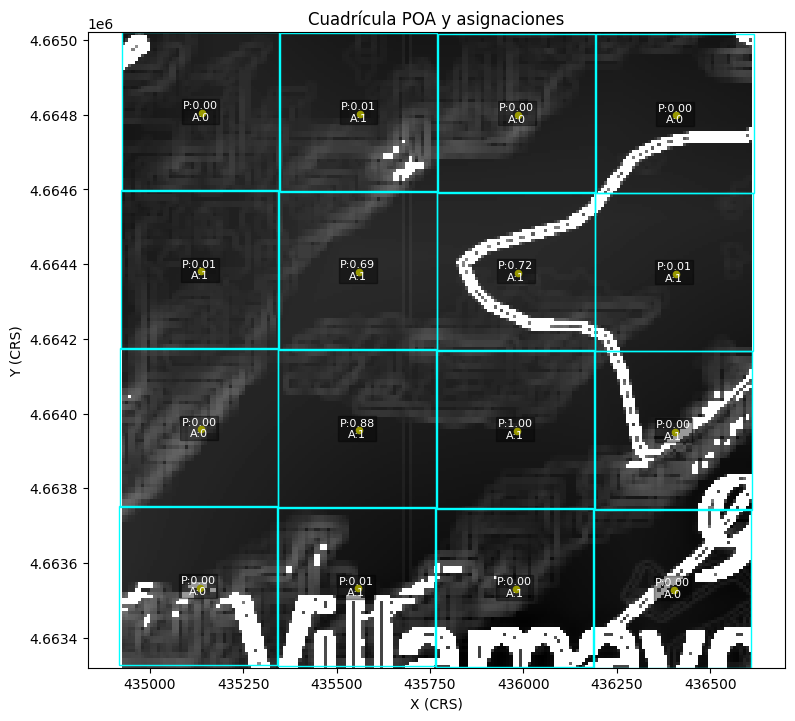

In [ ]:
# Supuestos: acc (acumulador de visitas) o acc_norm ya calculado,
# coste_final, transform, inicio y todos_caminos existen.

# 1) Normalizar acc a probabilidad por píxel si quieres (opcional)
acc_norm = acc / (acc.sum() if acc.sum() > 0 else 1.0)

# 2) Parámetros
n_responders = 10
zoom_px = 100
# si prefieres fijar A en lugar de calcularlo desde n_responders, pon A=3 por ejemplo
A = None   # o A = 3

# 3) Construir cuadrícula y asignar
assigned_cells, extent_geo, crop_idx = build_grid_and_assign(
    acc_array=acc_norm,        # usar acc o acc_norm según prefieras
    transform=transform,
    inicio=inicio,
    n_responders=n_responders,
    A=A,
    zoom_px=zoom_px,
    mode="one_per_cell_then_extra",
    use_prob_norm=True
)

# 4) Mostrar tabla resumen de celdas
import pandas as pd
df_cells = pd.DataFrame(assigned_cells)
# columnas útiles: grid_row, grid_col, poa, poa_norm, assigned, area_m2, area_km2, centroid_x, centroid_y
print(df_cells[["grid_row","grid_col","poa","poa_norm","assigned","area_m2","area_km2"]])

# 5) Plot con etiquetas
plot_grid_assignments(assigned_cells, extent_geo, acc_norm, transform, crop_idx, show_labels=True)


In [ ]:
# OTRA FORMA con menor número de pareclas, se ajusta al número de responsables

import numpy as np
import pandas as pd
from math import ceil, sqrt
from rasterio.transform import xy
from shapely.geometry import Point, box
import geopandas as gpd

def grid_size_from_responders(n_resp):
    """Devuelve A = ceil(sqrt(n_resp))."""
    return int(ceil(sqrt(max(1, n_resp))))

def split_crop_into_grid(acc_array, i_min, i_max, j_min, j_max, A):
    """
    Divide el recorte acc_array[i_min:i_max, j_min:j_max] en A x A celdas.
    Devuelve lista de dicts con índices de píxeles, POA (media), tamaño en píxels y centroides en índices.
    """
    crop = acc_array[i_min:i_max, j_min:j_max]
    h, w = crop.shape
    if h <= 0 or w <= 0:
        return []

    base_h = h // A
    base_w = w // A
    rem_h = h % A
    rem_w = w % A

    cells = []
    r0_rel = 0
    for ai in range(A):
        rh = base_h + (1 if ai < rem_h else 0)
        c0_rel = 0
        for aj in range(A):
            cw = base_w + (1 if aj < rem_w else 0)
            r1_rel = r0_rel + rh
            c1_rel = c0_rel + cw

            if rh <= 0 or cw <= 0:
                poa = 0.0
            else:
                block = crop[r0_rel:r1_rel, c0_rel:c1_rel]
                poa = float(np.nanmean(block)) if np.isfinite(block).any() else 0.0

            # centroid relativo al recorte
            r_cent_rel = r0_rel + rh / 2.0
            c_cent_rel = c0_rel + cw / 2.0

            cell = {
                "grid_row": ai,
                "grid_col": aj,
                "r0": int(r0_rel + i_min),
                "r1": int(r1_rel + i_min),
                "c0": int(c0_rel + j_min),
                "c1": int(c1_rel + j_min),
                "pixels_h": int(rh),
                "pixels_w": int(cw),
                "poa": poa,
                "r_cent_rel": r_cent_rel,
                "c_cent_rel": c_cent_rel,
                "r_cent": r_cent_rel + i_min,
                "c_cent": c_cent_rel + j_min
            }
            cells.append(cell)
            c0_rel = c1_rel
        r0_rel = r1_rel

    return cells

def cell_area_and_centroid_crs(cell, transform):
    """
    Calcula area en m2 y km2 y devuelve centroides en CRS.
    """
    px_w = transform.a
    px_h = abs(transform.e)
    area_m2 = cell["pixels_h"] * cell["pixels_w"] * px_w * px_h
    area_km2 = area_m2 / 1e6

    # centroid in CRS: transform * (col + 0.5, row + 0.5)
    col = cell["c_cent"]
    row = cell["r_cent"]
    x_cent, y_cent = transform * (col + 0.5, row + 0.5)

    # polygon bbox in CRS (top-left, bottom-right)
    x0, y0 = transform * (cell["c0"], cell["r0"])   # top-left
    x1, y1 = transform * (cell["c1"], cell["r1"])   # bottom-right
    # construir shapely box: box(minx, miny, maxx, maxy)
    minx, maxx = min(x0, x1), max(x0, x1)
    miny, maxy = min(y0, y1), max(y0, y1)
    geom = box(minx, miny, maxx, maxy)

    return area_m2, area_km2, x_cent, y_cent, geom

def build_grid_poa(acc_array, transform, inicio, zoom_px=100, A=None, n_responders=None, use_acc_norm=True):
    """
    Función de alto nivel:
      - recorta alrededor de inicio con zoom_px
      - calcula A si no se da y n_responders sí
      - devuelve GeoDataFrame con columnas: grid_row, grid_col, poa, poa_norm, assigned (inicial 0),
        area_m2, area_km2, centroid_x, centroid_y, geometry (polígono CRS), r0,r1,c0,c1
    """
    i0, j0 = inicio
    i_min, i_max = max(0, i0 - zoom_px), min(acc_array.shape[0], i0 + zoom_px)
    j_min, j_max = max(0, j0 - zoom_px), min(acc_array.shape[1], j0 + zoom_px)

    if A is None:
        if n_responders is None:
            raise ValueError("Indica A o n_responders")
        A = grid_size_from_responders(n_responders)

    cells = split_crop_into_grid(acc_array, i_min, i_max, j_min, j_max, A)
    rows = []
    poas = [c["poa"] for c in cells]
    maxp = max(poas) if len(poas) > 0 and max(poas) > 0 else 1.0

    for c in cells:
        area_m2, area_km2, x_cent, y_cent, geom = cell_area_and_centroid_crs(c, transform)
        row = {
            "grid_row": c["grid_row"],
            "grid_col": c["grid_col"],
            "r0": c["r0"], "r1": c["r1"], "c0": c["c0"], "c1": c["c1"],
            "pixels_h": c["pixels_h"], "pixels_w": c["pixels_w"],
            "poa": c["poa"],
            "poa_norm": c["poa"] / maxp,
            "area_m2": area_m2,
            "area_km2": area_km2,
            "centroid_x": x_cent,
            "centroid_y": y_cent,
            "geometry": geom,
            "assigned": 0
        }
        rows.append(row)

    gdf = gpd.GeoDataFrame(rows, crs=None, geometry=[r["geometry"] for r in rows])
    # eliminar la columna geometry duplicada en rows para evitar confusión
    gdf = gdf.drop(columns=["geometry"])
    gdf["geometry"] = [r["geometry"] for r in rows]
    # añadir índice ordenado por grid_row, grid_col
    gdf = gdf.sort_values(["grid_row", "grid_col"]).reset_index(drop=True)
    return gdf, (i_min, i_max, j_min, j_max)


In [ ]:
# Suponiendo que ya tienes acc (conteos) o acc_norm (probabilidades por píxel)
# Si tienes conteos y quieres probabilidad por píxel:
acc_norm = acc / (acc.sum() if acc.sum() > 0 else 1.0)

# Parámetros
zoom_px = 100
n_responders = None   # no asignamos todavía
A = 3                 # por ejemplo 3x3; si prefieres calcular desde n_responders pon A=None y n_responders=10

# Construir grid y obtener GeoDataFrame
gdf_cells, crop_idx = build_grid_poa(acc_norm, transform, inicio, zoom_px=zoom_px, A=A, n_responders=n_responders)

# Mostrar resumen
print(gdf_cells[["grid_row","grid_col","poa","poa_norm","area_m2","area_km2","centroid_x","centroid_y"]])


   grid_row  grid_col           poa  poa_norm        area_m2  area_km2  \
0         0         0  3.016306e-07  0.001506  321783.786149  0.321784   
1         0         1  4.121656e-06  0.020584  321783.786149  0.321784   
2         0         2  1.116357e-07  0.000558  316981.043072  0.316981   
3         1         0  4.421402e-06  0.022081  321783.786149  0.321784   
4         1         1  2.002350e-04  1.000000  321783.786149  0.321784   
5         1         2  4.859023e-06  0.024267  316981.043072  0.316981   
6         2         0  3.310796e-07  0.001653  316981.043072  0.316981   
7         2         1  8.310161e-06  0.041502  316981.043072  0.316981   
8         2         2  2.868796e-07  0.001433  312249.982728  0.312250   

      centroid_x    centroid_y  
0  435211.272876  4.664732e+06  
1  435778.532768  4.664729e+06  
2  436341.559379  4.664726e+06  
3  435208.500699  4.664165e+06  
4  435775.760592  4.664162e+06  
5  436338.787202  4.664159e+06  
6  435205.749210  4.663602e+

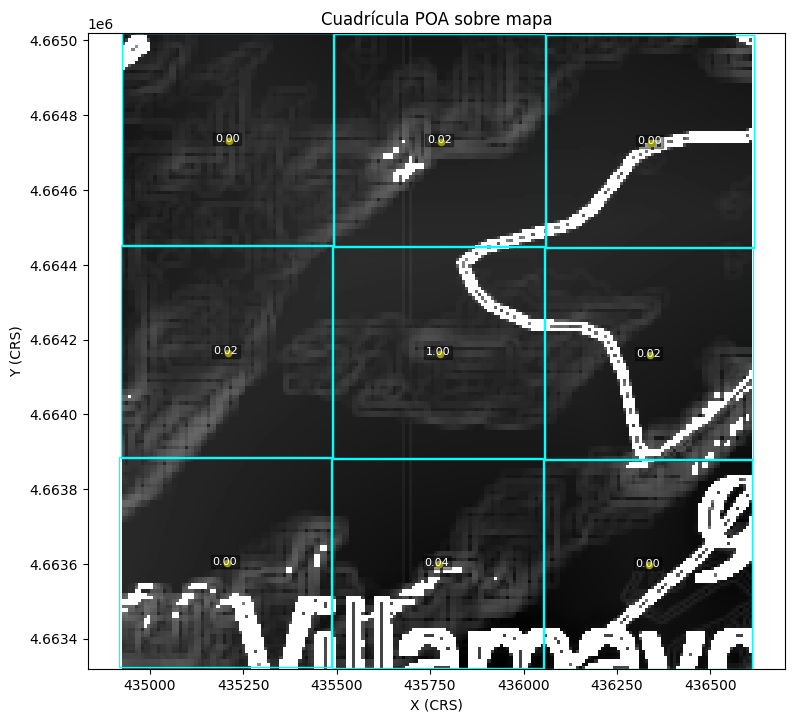

In [ ]:
import matplotlib.pyplot as plt

# extent en CRS para el recorte
i_min, i_max, j_min, j_max = crop_idx
x_min, y_max = transform * (j_min, i_min)
x_max, y_min = transform * (j_max, i_max)
extent_geo = [x_min, x_max, y_min, y_max]

fig, ax = plt.subplots(figsize=(9,9))
coste_crop = coste_final[i_min:i_max, j_min:j_max]
ax.imshow(coste_crop, cmap='gray', extent=extent_geo, origin='upper', interpolation='nearest')

# dibujar celdas y etiquetas POA
for idx, row in gdf_cells.iterrows():
    # rectángulo en CRS
    left = row["centroid_x"] - (row["area_m2"]**0.5)/2  # aproximación visual, mejor usar geometry.bounds
    # usar bounds reales de la geometría
    minx, miny, maxx, maxy = row.geometry.bounds
    rect = plt.Rectangle((minx, miny), maxx-minx, maxy-miny, edgecolor='cyan', facecolor='none', linewidth=1.0)
    ax.add_patch(rect)
    ax.text((minx+maxx)/2, (miny+maxy)/2, f"{row['poa_norm']:.2f}", color='white',
            ha='center', va='center', fontsize=8, bbox=dict(facecolor='black', alpha=0.4, pad=1))

# centroides
ax.scatter(gdf_cells["centroid_x"], gdf_cells["centroid_y"], color='yellow', s=20)

ax.set_title("Cuadrícula POA sobre mapa")
ax.set_xlabel("X (CRS)")
ax.set_ylabel("Y (CRS)")
ax.set_aspect('equal', adjustable='box')
plt.show()


# **HASTA AQUÍ  EL RESTO NO SE HA PODIDO PROBAR Y ADAPTAR CORRECTAMENTE A LOS OBJETIVOS --> PASOS PARA EL FUTURO**




## 7. Cálculo de POD


- poa:	Probabilidad por área (media del heatmap en la celda)
- difficulty:	Dificultad de búsqueda en la celda (0 fácil — 1 muy difícil)
- area_m2:	Tamaño de la celda en metros cuadrados
- priority:	poa * difficulty (mayor → más urgente)
- POD:	Probabilidad de detección con los recursos asignados
- POS:	Probabilidad de éxito = poa * POD
- assigned_pro:	Profesionales asignados (incluye 1 responsable)
- assigned_vol:	Voluntarios asignados




In [ ]:
import numpy as np
import pandas as pd
from math import ceil, log

# 1) Funciones básicas de cobertura y POD
def coverage_C(n_persons, distance_m_per_person, width_m, area_m2, difficulty=0.0):
    """
    Calcula C = (Z * W) / A ajustado por dificultad.
    - n_persons: número de personas asignadas a la celda
    - distance_m_per_person: distancia recorrida por persona (m)
    - width_m: ancho efectivo de detección (m)
    - area_m2: área de la celda (m2)
    - difficulty: [0,1] factor que reduce efectividad (1 = muy difícil)
    Estrategia: reducimos la cobertura efectiva multiplicando Z y W por (1 - difficulty).
    """
    if area_m2 <= 0:
        return 0.0
    eff_Z = distance_m_per_person * (1.0 - difficulty)
    eff_W = width_m * (1.0 - difficulty)
    C = (n_persons * eff_Z * eff_W) / area_m2
    return max(0.0, C)

def pod_from_C(C):
    """POD = 1 - exp(-C)"""
    return 1.0 - np.exp(-C)

def required_persons_for_target_pod(target_pod, distance_m_per_person, width_m, area_m2, difficulty=0.0):
    """
    Resuelve n >= (A * (-ln(1-target_pod))) / (Z*W*(1-difficulty))
    Devuelve entero ceil(n). Si target_pod >= 1.0 devuelve None.
    """
    if target_pod >= 1.0:
        return None
    if target_pod <= 0.0:
        return 0
    eff_Z = distance_m_per_person * (1.0 - difficulty)
    eff_W = width_m * (1.0 - difficulty)
    denom = eff_Z * eff_W
    if denom <= 0:
        return None
    C_needed = -np.log(1.0 - target_pod)
    n = (area_m2 * C_needed) / denom
    return int(ceil(max(0.0, n)))

# 2) Calcular POD y POS por celda dado un número asignado
def compute_cell_detection_metrics(df_cells,
                                   distance_m_per_person=2000.0,
                                   width_m=20.0,
                                   assigned_pro_col='assigned_pro',
                                   assigned_vol_col='assigned_vol',
                                   difficulty_col='difficulty'):
    """
    df_cells: DataFrame con columnas 'area_m2', 'poa', y difficulty_col (0..1).
    assigned_pro_col y assigned_vol_col indican cuántas personas de cada tipo están asignadas.
    distance_m_per_person: distancia recorrida por persona (m) — puede diferir entre pro/vol si quieres.
    width_m: ancho efectivo de detección (m).
    Devuelve df con columnas POD, POS, C.
    """
    df = df_cells.copy()
    df['n_assigned'] = df[assigned_pro_col].fillna(0).astype(int) + df[assigned_vol_col].fillna(0).astype(int)
    Cs = []
    PODs = []
    POSs = []
    for _, row in df.iterrows():
        n = int(row['n_assigned'])
        area = float(row['area_m2'])
        diff = float(row.get(difficulty_col, 0.0))
        C = coverage_C(n, distance_m_per_person, width_m, area, difficulty=diff)
        pod = pod_from_C(C)
        pos = float(row['poa']) * pod
        Cs.append(C); PODs.append(pod); POSs.append(pos)
    df['C'] = Cs
    df['POD'] = PODs
    df['POS'] = POSs
    return df

# 3) Calcular número óptimo de personas para alcanzar POD objetivo por celda
def compute_required_per_cell(df_cells, target_pod=0.95, distance_m_per_person=2000.0, width_m=20.0, difficulty_col='difficulty'):
    df = df_cells.copy()
    reqs = []
    for _, row in df.iterrows():
        area = float(row['area_m2'])
        diff = float(row.get(difficulty_col, 0.0))
        n_req = required_persons_for_target_pod(target_pod, distance_m_per_person, width_m, area, difficulty=diff)
        reqs.append(n_req if n_req is not None else np.nan)
    df['n_req_for_pod'] = reqs
    return df

# 4) Asignación de recursos (profesionales y voluntarios)
def allocate_resources(df_cells,
                       n_professionals,
                       n_volunteers,
                       min_professional_per_cell=True,
                       policy=None):
    """
    Estrategia de asignación:
      - df_cells: DataFrame con columnas 'poa', 'poa_norm', 'area_m2', 'difficulty' (opcional)
      - n_professionals, n_volunteers: recursos disponibles totales
      - min_professional_per_cell: si True, garantiza 1 profesional responsable por celda (si hay suficientes)
      - policy: dict con umbrales para priorizar (ejemplo abajo)
    Devuelve DataFrame con columnas assigned_pro, assigned_vol y priority.
    """
    df = df_cells.copy().reset_index(drop=True)
    # prioridad = poa * difficulty (si difficulty no existe usar 1)
    if 'difficulty' not in df.columns:
        df['difficulty'] = 1.0
    df['priority'] = df['poa'] * df['difficulty']
    df['assigned_pro'] = 0
    df['assigned_vol'] = 0

    # ordenar por prioridad descendente
    df = df.sort_values('priority', ascending=False).reset_index(drop=True)

    # 1) asignar 1 profesional responsable por celda si se pide
    if min_professional_per_cell:
        n_cells = len(df)
        to_assign = min(n_professionals, n_cells)
        df.loc[:to_assign-1, 'assigned_pro'] += 1
        n_professionals -= to_assign

    # 2) política para mandar más profesionales a zonas de mayor prioridad
    # policy ejemplo:
    # policy = {
    #   "high": {"thr":0.7, "prefer_pro": True},
    #   "mid": {"thr":0.4, "prefer_pro": True},
    #   "low": {"thr":0.0, "prefer_pro": False}
    # }
    if policy is None:
        policy = {
            "high": {"min_p": 0.7, "extra_pro_share": 0.6},
            "mid":  {"min_p": 0.4, "extra_pro_share": 0.3},
            "low":  {"min_p": 0.0, "extra_pro_share": 0.1}
        }

    # repartir profesionales extra por prioridad (proporcional a priority dentro de cada banda)
    if n_professionals > 0:
        # calcular banda para cada celda
        def band(p):
            if p >= policy['high']['min_p']:
                return 'high'
            elif p >= policy['mid']['min_p']:
                return 'mid'
            else:
                return 'low'
        df['band'] = df['priority'].apply(band)

        # calcular pesos por banda
        band_weights = {}
        for bname, bconf in policy.items():
            band_cells = df[df['band'] == bname]
            if len(band_cells) == 0:
                band_weights[bname] = 0.0
            else:
                band_weights[bname] = band_cells['priority'].sum()

        # repartir profesionales por banda proporcionalmente a band_weights
        total_weight = sum(band_weights.values())
        if total_weight == 0:
            # repartir uniformemente
            band_alloc = {b: 0 for b in band_weights}
            for k in range(n_professionals):
                bkeys = list(band_weights.keys())
                band_alloc[bkeys[k % len(bkeys)]] += 1
        else:
            band_alloc = {b: int(np.floor(n_professionals * (w / total_weight))) for b, w in band_weights.items()}
            # repartir restos
            rest = n_professionals - sum(band_alloc.values())
            # ordenar bandas por weight desc
            sorted_bands = sorted(band_weights.items(), key=lambda x: x[1], reverse=True)
            idx = 0
            while rest > 0:
                band_alloc[sorted_bands[idx][0]] += 1
                rest -= 1
                idx = (idx + 1) % len(sorted_bands)

        # dentro de cada banda repartir a celdas por prioridad
        for bname, n_alloc in band_alloc.items():
            if n_alloc <= 0:
                continue
            mask = df['band'] == bname
            sub = df[mask].copy()
            if sub['priority'].sum() == 0:
                # repartir uniformemente
                for k in range(n_alloc):
                    idx = sub.index[k % len(sub)]
                    df.at[idx, 'assigned_pro'] += 1
            else:
                frac = sub['priority'] / sub['priority'].sum()
                extras = np.floor(frac * n_alloc).astype(int)
                for idx_sub, e in zip(sub.index, extras):
                    df.at[idx_sub, 'assigned_pro'] += int(e)
                rest = n_alloc - extras.sum()
                # repartir restos por orden de prioridad
                for idx_sub in sub.sort_values('priority', ascending=False).index[:rest]:
                    df.at[idx_sub, 'assigned_pro'] += 1

    # 3) repartir voluntarios: preferir celdas de menor prioridad si policy lo indica,
    #    pero en general repartir proporcionalmente a priority o a (1-priority) según estrategia.
    # Aquí: repartir voluntarios proporcionalmente a priority pero con tope mínimo 0 por celda.
    if n_volunteers > 0:
        total_priority = df['priority'].sum()
        if total_priority == 0:
            # repartir uniformemente
            base = n_volunteers // len(df)
            rem = n_volunteers % len(df)
            df['assigned_vol'] += base
            for i in range(rem):
                df.at[i, 'assigned_vol'] += 1
        else:
            frac = df['priority'] / total_priority
            vols = np.floor(frac * n_volunteers).astype(int)
            for idx, v in zip(df.index, vols):
                df.at[idx, 'assigned_vol'] += int(v)
            rest = n_volunteers - vols.sum()
            for idx in df.sort_values('priority', ascending=False).index[:rest]:
                df.at[idx, 'assigned_vol'] += 1

    # 4) recalcular POD/POS con asignaciones finales
    df_final = df.copy()
    df_final = compute_cell_detection_metrics(df_final,
                                              distance_m_per_person=2000.0,
                                              width_m=20.0,
                                              assigned_pro_col='assigned_pro',
                                              assigned_vol_col='assigned_vol',
                                              difficulty_col='difficulty')
    # 5) probabilidad global de éxito (asumiendo independencia entre celdas)
    # P_success_global = 1 - product(1 - POS_cell)
    pos_vals = df_final['POS'].values
    p_global = 1.0 - np.prod(1.0 - pos_vals)
    df_final['cum_POS'] = pos_vals
    return df_final.sort_values('priority', ascending=False).reset_index(drop=True), p_global


In [ ]:
# Supuestos: gdf_cells (GeoDataFrame) con columnas: poa, area_m2, area_km2, centroid_x, centroid_y
# Añadimos una columna difficulty (0..1). Puedes definirla según pendiente, vegetación, obstáculos, etc.
gdf = gdf_cells.copy()
# ejemplo: difficulty = 0.5 para todas (ajusta según tu criterio)
gdf['difficulty'] = 0.5

# convertir a DataFrame plano para las funciones
df_cells = pd.DataFrame(gdf.drop(columns='geometry'))

# parámetros operativos
n_professionals = 8
n_volunteers = 20
distance_m_per_person = 2000.0   # cada persona recorre 2 km en la búsqueda
width_m = 20.0                   # ancho efectivo de detección
target_pod = 0.95

# 1) calcular cuántas personas serían necesarias por celda para POD objetivo (informativo)
df_req = compute_required_per_cell(df_cells, target_pod=target_pod,
                                   distance_m_per_person=distance_m_per_person,
                                   width_m=width_m, difficulty_col='difficulty')
print(df_req[['grid_row','grid_col','poa','difficulty','area_m2','n_req_for_pod']])

# 2) asignar recursos disponibles con la política por defecto
df_assigned, p_global = allocate_resources(df_cells,
                                           n_professionals=n_professionals,
                                           n_volunteers=n_volunteers,
                                           min_professional_per_cell=True,
                                           policy=None)
print("Probabilidad global de éxito estimada:", p_global)
print(df_assigned[['grid_row','grid_col','poa','difficulty','priority','assigned_pro','assigned_vol','POD','POS']])


   grid_row  grid_col           poa  difficulty        area_m2  n_req_for_pod
0         0         0  3.016306e-07         0.5  321783.786149             97
1         0         1  4.121656e-06         0.5  321783.786149             97
2         0         2  1.116357e-07         0.5  316981.043072             95
3         1         0  4.421402e-06         0.5  321783.786149             97
4         1         1  2.002350e-04         0.5  321783.786149             97
5         1         2  4.859023e-06         0.5  316981.043072             95
6         2         0  3.310796e-07         0.5  316981.043072             95
7         2         1  8.310161e-06         0.5  316981.043072             95
8         2         2  2.868796e-07         0.5  312249.982728             94
Probabilidad global de éxito estimada: 9.03852521041415e-05
   grid_row  grid_col           poa  difficulty      priority  assigned_pro  \
0         1         1  2.002350e-04         0.5  1.001175e-04             1   
1 

In [ ]:
# Calculo de cobertura y POS por celda
import numpy as np

def coverage_C(n, Z, W, area_m2, difficulty):
    eff = max(0.0, 1.0 - difficulty)
    return (n * Z * W * eff * eff) / area_m2 if area_m2>0 else 0.0

def pod_from_C(C):
    return 1.0 - np.exp(-C)


In [ ]:
# CELDA 1: Cálculo de cobertura C y POD por celda
import numpy as np
import pandas as pd
from math import ceil

# --- Funciones básicas ---
def coverage_C(n_persons, distance_m_per_person, width_m, area_m2, difficulty=0.0):
    """
    C = (n * Z * W * eff^2) / A, donde eff = 1 - difficulty
    """
    eff = max(0.0, 1.0 - float(difficulty))
    if area_m2 <= 0:
        return 0.0
    return (n_persons * distance_m_per_person * width_m * eff * eff) / area_m2

def pod_from_C(C):
    """POD = 1 - exp(-C)"""
    return 1.0 - np.exp(-C)

def required_persons_for_target_pod(target_pod, distance_m_per_person, width_m, area_m2, difficulty=0.0):
    """
    Devuelve ceil(n) necesario para POD >= target_pod usando la fórmula inversa.
    Si no es posible (denom 0) devuelve None.
    """
    if target_pod <= 0.0:
        return 0
    if target_pod >= 1.0:
        return None
    eff = (1.0 - float(difficulty))
    denom = distance_m_per_person * width_m * eff * eff
    if denom <= 0:
        return None
    C_needed = -np.log(1.0 - target_pod)
    n = (area_m2 * C_needed) / denom
    return int(ceil(max(0.0, n)))

# --- Preparar DataFrame df desde gdf_cells o df_cells ---
try:
    df = gdf_cells.copy()
    if 'geometry' in df.columns:
        df = pd.DataFrame(df.drop(columns=['geometry']))
except NameError:
    try:
        df = df_cells.copy()
    except NameError:
        raise RuntimeError("No encuentro 'gdf_cells' ni 'df_cells'. Crea la cuadrícula antes de ejecutar esta celda.")

# Columnas mínimas
if 'poa' not in df.columns:
    raise RuntimeError("Falta la columna 'poa' en df. Construye la cuadrícula primero.")
if 'area_m2' not in df.columns:
    raise RuntimeError("Falta la columna 'area_m2' en df. Construye la cuadrícula primero.")

# Inicializar columnas de asignación si no existen (0 por defecto)
if 'assigned_pro' not in df.columns:
    df['assigned_pro'] = 0
if 'assigned_vol' not in df.columns:
    df['assigned_vol'] = 0
if 'difficulty' not in df.columns:
    df['difficulty'] = 0.0

# Crear columna n_assigned (suma de profesionales + voluntarios)
df['n_assigned'] = df['assigned_pro'].fillna(0).astype(int) + df['assigned_vol'].fillna(0).astype(int)

# Parámetros operativos por defecto (ajusta si quieres)
Z_default = 2000.0   # distancia recorrida por persona (m)
W_default = 20.0     # ancho efectivo (m)

# Calcular C y POD con asignaciones actuales
df['C'] = df.apply(lambda r: coverage_C(int(r['n_assigned']), Z_default, W_default, float(r['area_m2']), float(r.get('difficulty',0.0))), axis=1)
df['POD'] = df['C'].apply(pod_from_C)

# Mostrar resumen
print("Primeras filas con C y POD calculados:")
print(df[['grid_row','grid_col','poa','area_m2','difficulty','n_assigned','C','POD']].head())


Primeras filas con C y POD calculados:
   grid_row  grid_col           poa        area_m2  difficulty  n_assigned  \
0         0         0  3.016306e-07  321783.786149         0.0           0   
1         0         1  4.121656e-06  321783.786149         0.0           0   
2         0         2  1.116357e-07  316981.043072         0.0           0   
3         1         0  4.421402e-06  321783.786149         0.0           0   
4         1         1  2.002350e-04  321783.786149         0.0           0   

     C  POD  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0  
4  0.0  0.0  


## 8. Cálculo de POS


In [ ]:
# CELDA 2: Cálculo de POS y n_req por celda para POD objetivo
import numpy as np

# Asegúrate de haber ejecutado la Celda 1 (df, coverage_C, pod_from_C, required_persons_for_target_pod están definidos)

# 1) Calcular POS por celda (usa 'poa' o 'poa_norm' según prefieras)
# Aquí usamos 'poa' tal como está (si quieres normalizar globalmente, normaliza antes)
df['POS'] = df['poa'] * df['POD']

# 2) Probabilidad global aproximada (asumiendo independencia entre celdas)
p_global = 1.0 - np.prod(1.0 - df['POS'].values)
print("Probabilidad global aproximada (sin cambios de asignación):", p_global)

# 3) Calcular número requerido por celda para alcanzar POD objetivo (informativo)
target_pod = 0.95
reqs = []
for _, row in df.iterrows():
    area = float(row['area_m2'])
    diff = float(row.get('difficulty', 0.0))
    n_req = required_persons_for_target_pod(target_pod, Z_default, W_default, area, difficulty=diff)
    reqs.append(n_req if n_req is not None else np.nan)
df['n_req_for_pod'] = reqs

# Mostrar resumen
print("\nPrimeras filas con POS y n_req_for_pod:")
print(df[['grid_row','grid_col','poa','area_m2','difficulty','POD','POS','n_req_for_pod']].head())


Probabilidad global aproximada (sin cambios de asignación): 0.0

Primeras filas con POS y n_req_for_pod:
   grid_row  grid_col           poa        area_m2  difficulty  POD  POS  \
0         0         0  3.016306e-07  321783.786149         0.0  0.0  0.0   
1         0         1  4.121656e-06  321783.786149         0.0  0.0  0.0   
2         0         2  1.116357e-07  316981.043072         0.0  0.0  0.0   
3         1         0  4.421402e-06  321783.786149         0.0  0.0  0.0   
4         1         1  2.002350e-04  321783.786149         0.0  0.0  0.0   

   n_req_for_pod  
0             25  
1             25  
2             24  
3             25  
4             25  


## 9. Asignación de recursos personales para cada área

In [ ]:
# CELDA 3: Asignación de recursos (greedy) y recálculo de POD/POS
import numpy as np
import pandas as pd
from math import floor

# --- Función de asignación ---
def allocate_resources(df_cells,
                       n_professionals,
                       n_volunteers,
                       min_professional_per_cell=True,
                       policy=None,
                       Z_pro=2000.0, W_pro=20.0,
                       Z_vol=1200.0, W_vol=15.0):
    """
    Reparte responsables (1 por celda si posible), profesionales extra y voluntarios.
    Devuelve DataFrame con assigned_pro, assigned_vol, C, POD, POS y p_global.
    """
    df_local = df_cells.copy().reset_index(drop=True)
    if 'difficulty' not in df_local.columns:
        df_local['difficulty'] = 0.0
    df_local['priority'] = df_local['poa'] * df_local['difficulty']
    df_local['assigned_pro'] = df_local.get('assigned_pro', 0).fillna(0).astype(int)
    df_local['assigned_vol'] = df_local.get('assigned_vol', 0).fillna(0).astype(int)

    # ordenar por prioridad descendente
    df_local = df_local.sort_values('priority', ascending=False).reset_index(drop=True)

    # 1) asignar 1 profesional responsable por celda si se pide
    if min_professional_per_cell:
        n_cells = len(df_local)
        to_assign = min(n_professionals, n_cells)
        if to_assign > 0:
            df_local.loc[:to_assign-1, 'assigned_pro'] += 1
            n_professionals -= to_assign

    # 2) política por defecto (bandas)
    if policy is None:
        policy = {
            "high": {"min_p": 0.7},
            "mid":  {"min_p": 0.4},
            "low":  {"min_p": 0.0}
        }

    # 3) repartir profesionales extra por bandas proporcionalmente a priority
    if n_professionals > 0:
        def band(p):
            if p >= policy['high']['min_p']:
                return 'high'
            elif p >= policy['mid']['min_p']:
                return 'mid'
            else:
                return 'low'
        df_local['band'] = df_local['priority'].apply(band)

        band_weights = {}
        for bname in policy.keys():
            band_cells = df_local[df_local['band'] == bname]
            band_weights[bname] = float(band_cells['priority'].sum()) if len(band_cells)>0 else 0.0

        total_weight = sum(band_weights.values())
        if total_weight == 0:
            # repartir uniformemente
            band_alloc = {b: 0 for b in band_weights}
            for k in range(n_professionals):
                bkeys = list(band_weights.keys())
                band_alloc[bkeys[k % len(bkeys)]] += 1
        else:
            band_alloc = {b: int(np.floor(n_professionals * (w / total_weight))) for b, w in band_weights.items()}
            rest = n_professionals - sum(band_alloc.values())
            sorted_bands = sorted(band_weights.items(), key=lambda x: x[1], reverse=True)
            idx = 0
            while rest > 0:
                band_alloc[sorted_bands[idx][0]] += 1
                rest -= 1
                idx = (idx + 1) % len(sorted_bands)

        # dentro de cada banda repartir a celdas por prioridad
        for bname, n_alloc in band_alloc.items():
            if n_alloc <= 0:
                continue
            mask = df_local['band'] == bname
            sub = df_local[mask].copy()
            if sub.shape[0] == 0:
                continue
            if sub['priority'].sum() == 0:
                for k in range(n_alloc):
                    idx = sub.index[k % len(sub)]
                    df_local.at[idx, 'assigned_pro'] += 1
            else:
                frac = sub['priority'] / sub['priority'].sum()
                extras = np.floor(frac * n_alloc).astype(int)
                for idx_sub, e in zip(sub.index, extras):
                    df_local.at[idx_sub, 'assigned_pro'] += int(e)
                rest = n_alloc - extras.sum()
                for idx_sub in sub.sort_values('priority', ascending=False).index[:rest]:
                    df_local.at[idx_sub, 'assigned_pro'] += 1

    # 4) repartir voluntarios proporcionalmente a priority
    if n_volunteers > 0:
        total_priority = df_local['priority'].sum()
        if total_priority == 0:
            base = n_volunteers // len(df_local)
            rem = n_volunteers % len(df_local)
            df_local['assigned_vol'] += base
            for i in range(rem):
                df_local.at[i, 'assigned_vol'] += 1
        else:
            frac = df_local['priority'] / total_priority
            vols = np.floor(frac * n_volunteers).astype(int)
            for idx, v in zip(df_local.index, vols):
                df_local.at[idx, 'assigned_vol'] += int(v)
            rest = n_volunteers - vols.sum()
            for idx in df_local.sort_values('priority', ascending=False).index[:rest]:
                df_local.at[idx, 'assigned_vol'] += 1

    # 5) recalcular C/POD/POS usando efectividad distinta para pro/vol
    Cs = []
    PODs = []
    POSs = []
    for _, row in df_local.iterrows():
        n_pro = int(row['assigned_pro'])
        n_vol = int(row['assigned_vol'])
        area = float(row['area_m2'])
        diff = float(row.get('difficulty', 0.0))
        C_pro = coverage_C(n_pro, Z_pro, W_pro, area, difficulty=diff)
        C_vol = coverage_C(n_vol, Z_vol, W_vol, area, difficulty=diff)
        C = C_pro + C_vol
        pod = pod_from_C(C)
        pos = float(row['poa']) * pod
        Cs.append(C); PODs.append(pod); POSs.append(pos)
    df_local['C'] = Cs
    df_local['POD'] = PODs
    df_local['POS'] = POSs

    # 6) probabilidad global de éxito (independencia aproximada)
    p_global = 1.0 - np.prod(1.0 - df_local['POS'].values)
    return df_local.sort_values('priority', ascending=False).reset_index(drop=True), p_global



In [ ]:
# --- EJEMPLO DE USO ---
# Ajusta estos números a tus recursos reales
n_professionals = 8   # total profesionales disponibles (incluye responsables)
n_volunteers = 20     # total voluntarios disponibles

df_assigned, p_global_after = allocate_resources(df,
                                                 n_professionals=n_professionals,
                                                 n_volunteers=n_volunteers,
                                                 min_professional_per_cell=True,
                                                 policy=None,
                                                 Z_pro=Z_default, W_pro=W_default,
                                                 Z_vol=1200.0, W_vol=15.0)

print("Probabilidad global tras asignación:", p_global_after)
print("\nAsignación (primeras filas):")
print(df_assigned[['grid_row','grid_col','poa','difficulty','priority','assigned_pro','assigned_vol','C','POD','POS']].head())


Probabilidad global tras asignación: 4.7105757105314616e-05

Asignación (primeras filas):
   grid_row  grid_col           poa  difficulty  priority  assigned_pro  \
0         0         0  3.016306e-07         0.0       0.0             1   
1         0         1  4.121656e-06         0.0       0.0             1   
2         0         2  1.116357e-07         0.0       0.0             1   
3         1         0  4.421402e-06         0.0       0.0             1   
4         1         1  2.002350e-04         0.0       0.0             1   

   assigned_vol         C       POD           POS  
0             3  0.292122  0.253322  7.640975e-08  
1             3  0.292122  0.253322  1.044107e-06  
2             2  0.239762  0.213185  2.379904e-08  
3             2  0.236183  0.210364  9.301046e-07  
4             2  0.236183  0.210364  4.212226e-05  


# E. Conclusiones
---

XXXX